# QREV v3.1.1 - reverberation-related residual tail and modulation smearing

**Scientific question.** Does energy persist after natural speech offsets,
or does the speech modulation spectrum change, in a pattern compatible with
reverberation or echo?

QREV is a four-feature profile, not a scalar score. Three **conditional**
natural-boundary features describe post-offset magnitude, bounded
persistence, and downward decay when sufficiently long, stable pauses are
present. The fourth is a broadly available, pinned normalized SRMR
comparator. These no-reference descriptors do not estimate RT60, EDT,
C50/C80, D50, DRR, STI, or a room impulse response. They also do not detect,
localize, or separately quantify discrete-delay echo.

The authoritative implementation is `paper1_qc.qrev`. This notebook never
redefines the algorithms. It validates formulas, the pinned SRMR runtime,
simulated RIR responses, discriminant controls, censoring, codec behavior,
support-tier precision, availability transitions, the frozen cohort, and a
label-blind reviewer gallery. Natural-boundary availability may depend on
speech-offset characteristics; its association with ALS severity is
explicitly reserved for downstream missingness analysis. Human quality
annotations and clinical labels are not used here.


## 0. Environment, controls, and common output contract


In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
from tempfile import TemporaryDirectory
import gc
import hashlib
import importlib.metadata
import json
import math
import shutil
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal, stats
from scipy.io import loadmat
from IPython.display import Markdown, display
import yaml


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (
            (candidate / "pyproject.toml").exists()
            and (candidate / "src" / "paper1_qc").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Open this notebook from inside the paper1 repository."
    )


ROOT = find_project_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from paper1_qc.feature_validation import (
    OKABE_ITO,
    ValidationCheck,
    gate_passed,
    save_publication_figure,
    save_table_bundle,
    set_publication_style,
    sha256_file,
    validation_frame,
    write_json,
)
from paper1_qc.media import decode_audio_views
from paper1_qc.qrev import (
    ANALYSIS_FEATURES,
    BROADLY_AVAILABLE_COMPARATOR_FEATURES,
    CONDITIONAL_BOUNDARY_FEATURES,
    DEFAULT_PARAMETERS,
    FEATURE_DEFINITIONS,
    MEASUREMENT_VERSION,
    PRIMARY_FEATURES,
    SRMR_GAMMATONE_VERSION,
    SRMR_PINNED_REGRESSION_VALUE,
    SRMR_UPSTREAM_COMMIT,
    SRMR_VARIANT,
    TimeInterval,
    apply_gain_db,
    boundary_envelope_trace,
    compute_srmr_norm,
    estimate_srmr_working_set_mb,
    extract_qrev,
    feature_registry_frame,
    internal_pause_boundaries,
)

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 240)
set_publication_style()

CONFIG = ROOT / "config" / "project.yaml"
MAIN_OUTPUTS = ROOT / "MAIN outputs"
ESTIMATOR_IMPLEMENTATION_VERSION = MEASUREMENT_VERSION
VALIDATION_RELEASE = "qrev-v3.1.1"
if ESTIMATOR_IMPLEMENTATION_VERSION != "qrev-v3.1.0":
    raise RuntimeError(
        "QREV v3.1.1 is a validation-only revision and expects "
        "the tested qrev-v3.1.0 estimator implementation."
    )
STAGE = (
    ROOT / "outputs" / "02_features" / "reverberation"
    / VALIDATION_RELEASE
)
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
GALLERY = STAGE / "gallery"
AUDIT = STAGE / "audit"
CHECKPOINTS = AUDIT / "recording_checkpoints"
for directory in [TABLES, FIGURES, GALLERY, AUDIT, CHECKPOINTS]:
    directory.mkdir(parents=True, exist_ok=True)

RUN_COHORT_EXTRACTION = True
RUN_CODEC_ROUNDTRIP = True
RUN_PACKAGE_TESTS = True
PACKAGE_TESTS_CONFIRMED = False
BUILD_GALLERY = True
MAX_ROBUSTNESS_AVAILABLE_RECORDINGS = 120
MAX_ROBUSTNESS_UNAVAILABLE_RECORDINGS = 40
MINIMUM_ROBUSTNESS_PAIRED_N = 30
RESUME_FROM_CHECKPOINTS = True

# The first run must remain a candidate. Change only after reviewing the
# complete outputs and gallery.
PUBLISH_AND_FREEZE_QREV_V311 = True
PACKAGE_INTEGRATION_APPROVED = False

QREV_REVIEW_DECISION = "ACCEPT_QREV_V311"
QREV_REVIEWER = "Nevena Musikic"
QREV_REVIEW_RATIONALE = (
    "All technical, scientific, empirical, robustness, codec, support, "
    "and gallery-construction gates passed. The label-blind gallery was "
    "reviewed across feature quantiles, unavailable recordings, and "
    "minimum-support cases. Conditional availability, boundary sensitivity, "
    "feature redundancy, and SRMR noise sensitivity were accepted within "
    "the predefined claim boundaries."
)

PARAMETERS = DEFAULT_PARAMETERS
FS = PARAMETERS.analysis_sample_rate_hz
RNG = np.random.default_rng(PARAMETERS.random_seed)

print("Project:", ROOT)
print("Validation release:", VALIDATION_RELEASE)
print("Estimator implementation:", ESTIMATOR_IMPLEMENTATION_VERSION)
print("Cohort extraction:", RUN_COHORT_EXTRACTION)
print("Resume checkpoints:", RESUME_FROM_CHECKPOINTS)
print("Outputs:", STAGE)


Project: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1
Validation release: qrev-v3.1.1
Estimator implementation: qrev-v3.1.0
Cohort extraction: True
Resume checkpoints: True
Outputs: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\reverberation\qrev-v3.1.1


## 1. Immutable feature registry and scientific claim boundaries


In [2]:
feature_registry = feature_registry_frame()
parameter_table = pd.DataFrame([
    {
        "parameter": key,
        "value": (
            json.dumps(value)
            if isinstance(value, (list, dict))
            else value
        ),
    }
    for key, value in PARAMETERS.to_dict().items()
])
save_table_bundle(feature_registry, TABLES, "qrev_v311_feature_registry")
save_table_bundle(parameter_table, TABLES, "qrev_v311_parameters")
write_json(PARAMETERS.to_dict(), AUDIT / "qrev_v311_parameters.json")

forbidden_components = {
    "rt60", "edt", "c50", "c80", "d50", "drr", "sti",
    "score", "composite", "burden",
}
registry_checks = validation_frame([
    ValidationCheck(
        "registry",
        "exactly four prespecified analysis features",
        tuple(feature_registry["name"]) == tuple(ANALYSIS_FEATURES),
        str(feature_registry["name"].tolist()),
        str(list(ANALYSIS_FEATURES)),
        "repair registry/package mismatch",
    ),
    ValidationCheck(
        "registry",
        "no scalar score or room-parameter feature",
        not any(
            forbidden_components.intersection(name.split("_"))
            for name in feature_registry["name"].astype(str)
        ),
        "absent",
        "absent",
        "remove forbidden construct",
    ),
    ValidationCheck(
        "registry",
        "SRMR variant is explicit in feature name",
        "qrev_srmr_norm" in ANALYSIS_FEATURES,
        "qrev_srmr_norm",
        "normalized variant encoded",
        "rename feature and regenerate",
    ),
    ValidationCheck(
        "registry",
        "natural-boundary features are explicitly conditional",
        set(CONDITIONAL_BOUNDARY_FEATURES) == set(
            feature_registry.loc[
                feature_registry["role"].str.contains(
                    "conditional", case=False, na=False
                ),
                "name",
            ]
        ),
        str(list(CONDITIONAL_BOUNDARY_FEATURES)),
        "all three natural-boundary features",
        "repair feature roles",
    ),
    ValidationCheck(
        "registry",
        "SRMR is the broadly available comparator",
        set(BROADLY_AVAILABLE_COMPARATOR_FEATURES) == set(
            feature_registry.loc[
                feature_registry["role"].str.contains(
                    "broadly available", case=False, na=False
                ),
                "name",
            ]
        ),
        str(list(BROADLY_AVAILABLE_COMPARATOR_FEATURES)),
        "qrev_srmr_norm only",
        "repair comparator role",
    ),
])
display(feature_registry)
display(registry_checks)


,name,display_name,subdomain,role,unit,maturity,estimand,orientation,claim_boundary,minimum_support,known_confounds
0,qrev_tail_excess_100ms_db,Early post-offset tail excess,residual magnitude,primary conditional,dB,study-specific residual-tail proxy,Median signed difference between the first 100...,Higher indicates stronger early residual energ...,Conditional blind residual-tail proxy; not RT6...,At least four valid boundaries and 2.0 s eligi...,"Breath, noise change, echo, speech leakage, of..."
1,qrev_tail_persistence_median_sec,Bounded tail persistence,residual persistence,primary conditional,s,study-specific censored persistence estimator,Median time until the frame envelope first rem...,Higher indicates longer observable above-floor...,"Conditional feature, not reverberation time; a...",At least four valid full-horizon boundaries.,"Echo, breath, changing noise, pause length, fl..."
2,qrev_downward_decay_rate_db_per_sec,Conditional downward tail-decay rate,decay shape,secondary conditional,dB/s,study-specific robust slope,Median magnitude of a negative Theil-Sen slope...,Lower positive magnitude indicates slower vali...,"Conditional feature, not a Schroeder decay or ...",At least four eligible downward-decay boundaries.,"Nonsmooth echo, floor crossing, breath, insuff..."
3,qrev_srmr_norm,Normalized speech-to-reverberation modulation ...,modulation smearing,broadly available established comparator,ratio,published no-reference metric; pinned implemen...,Normalized-fast SRMRpy ratio over the natural ...,Typically lower indicates more reverberation-r...,No-reference reverberation-sensitive comparato...,At least 3.0 s frozen speech and a 3.0-s task ...,"Additive noise, codec, speech content, bandwid..."


,layer,check,passed,observed,required,action_if_failed,blocking
0,registry,exactly four prespecified analysis features,True,"['qrev_tail_excess_100ms_db', 'qrev_tail_persi...","['qrev_tail_excess_100ms_db', 'qrev_tail_persi...",repair registry/package mismatch,True
1,registry,no scalar score or room-parameter feature,True,absent,absent,remove forbidden construct,True
2,registry,SRMR variant is explicit in feature name,True,qrev_srmr_norm,normalized variant encoded,rename feature and regenerate,True
3,registry,natural-boundary features are explicitly condi...,True,"['qrev_tail_excess_100ms_db', 'qrev_tail_persi...",all three natural-boundary features,repair feature roles,True
4,registry,SRMR is the broadly available comparator,True,['qrev_srmr_norm'],qrev_srmr_norm only,repair comparator role,True


### Operational definitions

Frame level is AC-RMS in dBFS:

\[
L_t=20\log_{10}\sqrt{\frac{1}{N}
\sum_{n=1}^{N}(x_n-\bar{x})^2}.
\]

At each valid natural speech-to-pause boundary, early tail excess is
\(\mathrm{median}(L_{0:100\,ms})-
\mathrm{median}(L_{700:1000\,ms})\). The signed difference is retained.

Persistence is the first 30-ms frame midpoint at which three consecutive
frames are within 3 dB of the local floor; absence of a crossing is
right-censored at 1.0 s. The decay feature is the magnitude of a negative
Theil-Sen slope over 0-300 ms, conditional on at least 3 dB robust dynamic
range. Recording values are medians over eligible boundaries.

`qrev_srmr_norm` uses official SRMRpy source at commit
`fee009779cef96bed34db3a7e31d10f3ad1ea133` with Gammatone 1.0.3,
`fast=True`, `norm=True`, `max_cf=30`, 23 cochlear filters, and a
4-30-Hz modulation filterbank. It is computed over the natural task span
from first speech onset to last speech offset, preserving internal pauses.

Supporting literature: Falk, Zheng, and Chan (2010),
doi:10.1109/TASL.2010.2052247; Santos, Senoussaoui, and Falk (2014);
Senoussaoui, Santos, and Falk (2015), arXiv:1510.04707; Falk and Chan
(2010), doi:10.1109/TIM.2009.2024697. The exact boundary aggregations are
study-specific and are not presented as standardized room-acoustic
measurements. The natural-boundary features are conditional rather than
universal recording descriptors; SRMR is the only QREV feature designed
for broad cohort coverage.

A delayed echo can raise the tail features, but QREV contains no
discrete-delay echo detector. The allowed interpretation is therefore
reverberation- or echo-compatible residual behavior, not identification
of either artifact.


## 2. Formula, transform, determinism, and SRMR reference validation


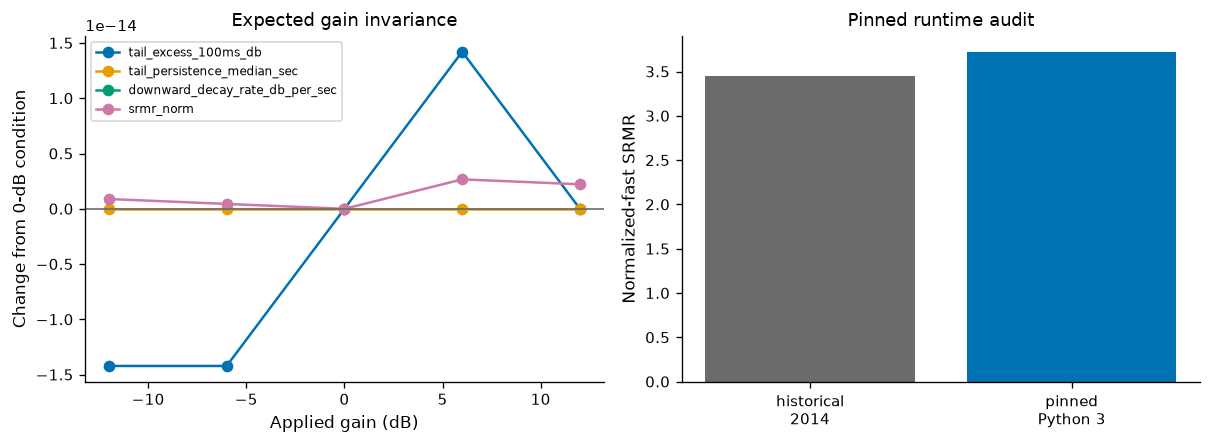

,srmrpy_upstream_commit,required_gammatone_version,installed_gammatone_version,variant,pinned_python3_regression_value,observed_value,absolute_regression_error,upstream_2014_historical_fixture,historical_fixture_difference,historical_discrepancy_status
0,fee009779cef96bed34db3a7e31d10f3ad1ea133,1.0.3,1.0.3,SRMRpy normalized-fast; norm=True; fast=True; ...,3.715814,3.715814,9.325873e-15,3.44954,0.266274,documented_dependency_era_difference_not_used_...


,layer,check,passed,observed,required,action_if_failed,blocking
0,formula,all four analysis features are gain invariant,True,1.421e-14,<1e-8,repair transform or support behavior,True
1,formula,extraction is deterministic,True,True,True,remove stochastic estimator behavior,True
2,reference,pinned SRMR runtime regression,True,3.715814103437,3.715814103437,restore pinned source/dependency environment,True
3,reference,historical SRMR fixture discrepancy is explicit,True,0.266274,recorded and nonzero,do not claim false historical reproduction,True


In [3]:
def synthetic_task(
    speech_count=6,
    speech_sec=0.8,
    pause_sec=1.2,
    floor_level=2e-5,
    seed=12,
):
    rng = np.random.default_rng(seed)
    duration = speech_count*speech_sec + (speech_count-1)*pause_sec
    waveform = floor_level*rng.standard_normal(round(duration*FS))
    intervals, cursor = [], 0.0
    for index in range(speech_count):
        start, end = cursor, cursor + speech_sec
        intervals.append(TimeInterval(start, end))
        left, right = round(start*FS), round(end*FS)
        time = np.arange(right-left)/FS
        waveform[left:right] += 0.025*(
            np.sin(2*np.pi*173*time)
            + 0.55*np.sin(2*np.pi*421*time + 0.3)
            + 0.25*np.sin(2*np.pi*911*time + 0.7)
        )
        cursor = end + (pause_sec if index < speech_count-1 else 0)
    return waveform, intervals


base_waveform, synthetic_intervals = synthetic_task()
gain_rows = []
for gain_db in [-12, -6, 0, 6, 12]:
    result = extract_qrev(
        apply_gain_db(base_waveform, gain_db),
        FS,
        strict_speech=synthetic_intervals,
        logical_recording_id=f"gain_{gain_db}",
        compute_srmr=True,
    ).recording
    gain_rows.append({
        "applied_gain_db": gain_db,
        **{feature: result[feature] for feature in ANALYSIS_FEATURES},
    })
gain_controls = pd.DataFrame(gain_rows)
baseline = gain_controls.loc[gain_controls["applied_gain_db"].eq(0)].iloc[0]
finite_errors = []
for feature in ANALYSIS_FEATURES:
    values = gain_controls[feature].to_numpy(float)
    if np.isfinite(values).all():
        finite_errors.append(np.max(np.abs(values - baseline[feature])))
invariant_error = max(finite_errors) if finite_errors else np.inf

fixture_dir = ROOT / "tests" / "fixtures" / "srmrpy"
fixture_signal = loadmat(fixture_dir / "test.mat")["s"][:, 0]
historical_fixture = float(
    loadmat(fixture_dir / "correct_ratios.mat")["correct_ratios"][0, 2]
)
current_fixture = compute_srmr_norm(fixture_signal, FS)
installed_gammatone_version = importlib.metadata.version("Gammatone")
srmr_reference_audit = pd.DataFrame([{
    "srmrpy_upstream_commit": SRMR_UPSTREAM_COMMIT,
    "required_gammatone_version": SRMR_GAMMATONE_VERSION,
    "installed_gammatone_version": installed_gammatone_version,
    "variant": SRMR_VARIANT,
    "pinned_python3_regression_value": SRMR_PINNED_REGRESSION_VALUE,
    "observed_value": current_fixture,
    "absolute_regression_error": abs(
        current_fixture - SRMR_PINNED_REGRESSION_VALUE
    ),
    "upstream_2014_historical_fixture": historical_fixture,
    "historical_fixture_difference": current_fixture-historical_fixture,
    "historical_discrepancy_status": (
        "documented_dependency_era_difference_not_used_as_pass_target"
    ),
}])

repeated = [
    extract_qrev(
        base_waveform, FS,
        strict_speech=synthetic_intervals,
        logical_recording_id="repeat",
        compute_srmr=True,
    )
    for _ in range(2)
]
deterministic = (
    repeated[0].recording == repeated[1].recording
    and repeated[0].boundary_ledger.equals(repeated[1].boundary_ledger)
)
formula_checks = validation_frame([
    ValidationCheck(
        "formula", "all four analysis features are gain invariant",
        invariant_error < 1e-8,
        f"{invariant_error:.3e}",
        "<1e-8",
        "repair transform or support behavior",
    ),
    ValidationCheck(
        "formula", "extraction is deterministic",
        deterministic,
        str(deterministic),
        "True",
        "remove stochastic estimator behavior",
    ),
    ValidationCheck(
        "reference", "pinned SRMR runtime regression",
        (
            installed_gammatone_version == SRMR_GAMMATONE_VERSION
            and abs(
                current_fixture-SRMR_PINNED_REGRESSION_VALUE
            ) < 1e-9
        ),
        f"{current_fixture:.12f}",
        f"{SRMR_PINNED_REGRESSION_VALUE:.12f}",
        "restore pinned source/dependency environment",
    ),
    ValidationCheck(
        "reference", "historical SRMR fixture discrepancy is explicit",
        abs(current_fixture-historical_fixture) > 0.20,
        f"{current_fixture-historical_fixture:.6f}",
        "recorded and nonzero",
        "do not claim false historical reproduction",
    ),
])
save_table_bundle(gain_controls, TABLES, "qrev_v311_gain_controls")
save_table_bundle(
    srmr_reference_audit, TABLES, "qrev_v311_srmr_reference_audit"
)
save_table_bundle(formula_checks, TABLES, "qrev_v311_formula_checks")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8))
for feature, color in zip(
    ANALYSIS_FEATURES,
    [
        OKABE_ITO["blue"], OKABE_ITO["orange"],
        OKABE_ITO["green"], OKABE_ITO["purple"],
    ],
):
    axes[0].plot(
        gain_controls["applied_gain_db"],
        gain_controls[feature]-baseline[feature],
        "o-", label=feature.replace("qrev_", ""), color=color,
    )
axes[0].axhline(0, color=OKABE_ITO["grey"], linewidth=1)
axes[0].set(
    xlabel="Applied gain (dB)",
    ylabel="Change from 0-dB condition",
    title="Expected gain invariance",
)
axes[0].legend(fontsize=7)
axes[1].bar(
    ["historical\n2014", "pinned\nPython 3"],
    [historical_fixture, current_fixture],
    color=[OKABE_ITO["grey"], OKABE_ITO["blue"]],
)
axes[1].set(ylabel="Normalized-fast SRMR", title="Pinned runtime audit")
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qrev_formula_transform_validation",
    caption=(
        "QREV v3.1 transform and SRMR runtime validation. All analysis "
        "features are invariant to unclipped digital gain. The SRMR panel "
        "shows the explicitly documented dependency-era fixture difference."
    ),
    alt_text=(
        "Gain-invariance curves for four QREV features and a bar comparison "
        "of the historical and pinned Python-3 SRMR fixture values."
    ),
)
plt.show()
display(srmr_reference_audit)
display(formula_checks)


## 3. Factorial RIR construct validity and discriminant controls

Two RIR experiments separate residual-tail energy from decay time. Every
dose uses the same stochastic tail realization. Tail energy is normalized
before dose scaling, the dry waveform is prepared with headroom once, and
no condition-specific peak normalization is allowed.

Expected response matrix:

| Manipulation | Tail excess | Persistence | Downward rate | SRMR |
|---|---:|---:|---:|---:|
| More tail energy, fixed decay | increase | nondecrease | no required order | decrease |
| Longer decay, fixed tail energy | no required order | increase | decrease | decrease |

Breath, additive noise, and echo controls characterize known confounds;
they are not used to tune thresholds.


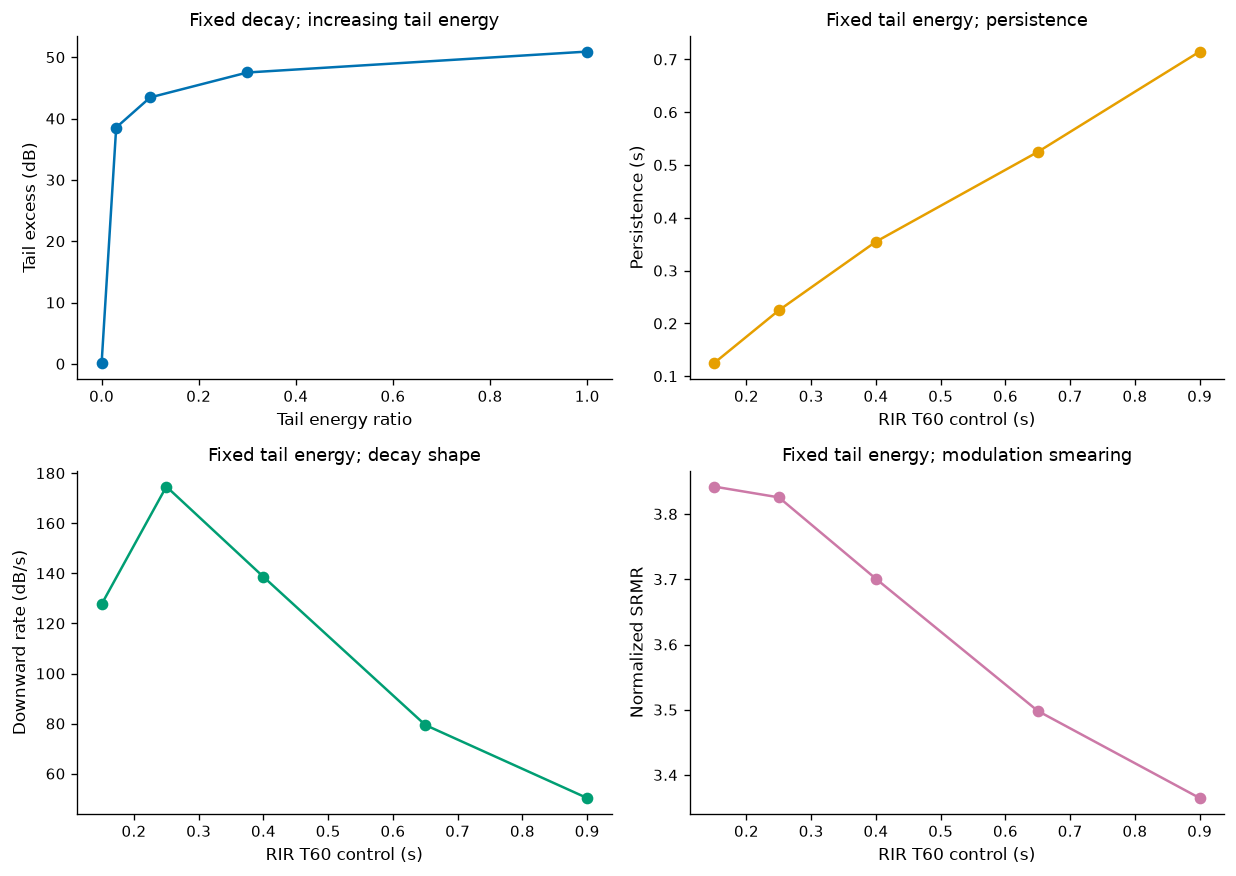

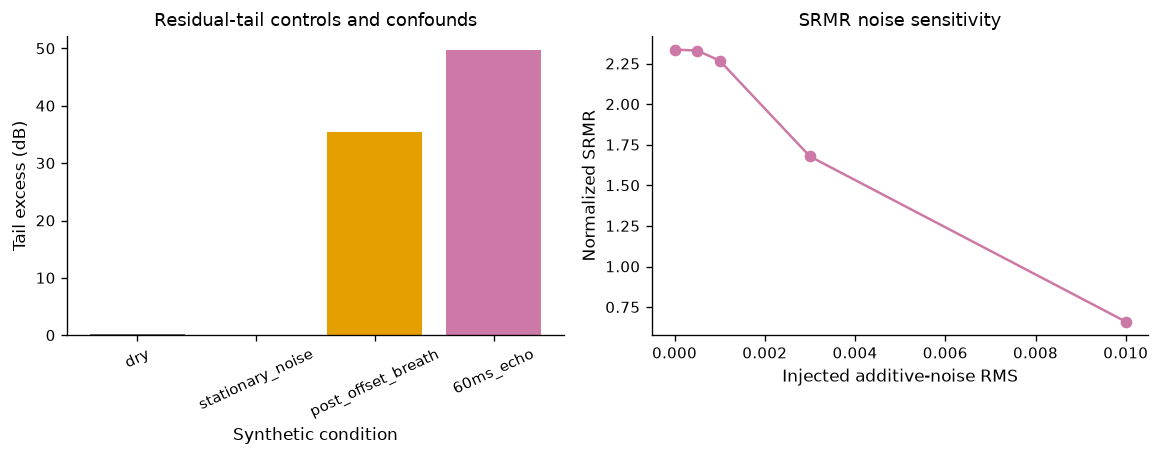

,experiment,dose,peak_absolute_amplitude,qrev_tail_excess_100ms_db,qrev_tail_persistence_median_sec,qrev_downward_decay_rate_db_per_sec,qrev_srmr_norm,tail_boundary_count,persistence_boundary_count,decay_boundary_count,persistence_censored_fraction
0,tail_energy_fixed_t60,0.00,0.044942,0.135267,0.015,NaN,3.718680,5,5,0,0.0
1,tail_energy_fixed_t60,0.03,0.047686,38.551942,0.365,121.170570,3.740335,5,5,5,0.0
2,tail_energy_fixed_t60,0.10,0.050902,43.459721,0.385,122.759413,3.655435,5,5,5,0.0
3,tail_energy_fixed_t60,0.30,0.056107,47.523420,0.395,123.038603,3.385734,5,5,5,0.0
4,tail_energy_fixed_t60,1.00,0.068556,50.934516,0.415,123.115481,2.812297,5,5,5,0.0
5,t60_fixed_tail_energy,0.15,0.052588,30.035163,0.125,127.696692,3.842170,5,5,5,0.0
6,t60_fixed_tail_energy,0.25,0.052044,38.264726,0.225,174.660293,3.825615,5,5,5,0.0
7,t60_fixed_tail_energy,0.40,0.051161,42.674229,0.355,138.598363,3.700799,5,5,5,0.0
8,t60_fixed_tail_energy,0.65,0.050056,45.127842,0.525,79.451116,3.498250,5,5,5,0.0
9,t60_fixed_tail_energy,0.90,0.049303,45.251888,0.715,50.279362,3.364743,5,5,5,0.0


,condition,qrev_tail_excess_100ms_db,qrev_tail_persistence_median_sec,qrev_downward_decay_rate_db_per_sec,qrev_srmr_norm
0,dry,0.135267,0.015,NaN,2.336110
1,stationary_noise,0.049820,0.015,NaN,2.253047
2,post_offset_breath,35.514039,0.175,152.205247,2.314146
3,60ms_echo,49.681816,0.075,3.966644,2.463332


,injected_noise_rms,qrev_srmr_norm,qrev_tail_excess_100ms_db
0,0.0000,2.336110,0.135267
1,0.0005,2.330461,0.008505
2,0.0010,2.268044,0.007117
3,0.0030,1.678092,0.006402
4,0.0100,0.660412,0.006192


,layer,check,passed,observed,required,action_if_failed,blocking
0,construct,tail excess orders fixed-decay tail-energy dose,True,rho=1.000,rho>=0.80,revise tail estimator or RIR experiment,True
1,construct,persistence does not reverse with stronger fix...,True,rho=1.000,rho>=0 or constant ceiling,revise persistence estimator,True
2,construct,SRMR decreases with fixed-decay tail-energy dose,True,rho=-0.900,rho<=-0.70,inspect SRMR implementation/control range,True
3,construct,persistence orders fixed-energy decay dose,True,rho=1.000,rho>=0.70,revise persistence estimator or RIR range,True
4,construct,conditional downward rate slows with longer decay,True,rho=-0.700,rho<=-0.70,revise conditional decay estimator,True
5,construct,SRMR decreases with fixed-energy decay dose,True,rho=-1.000,rho<=-0.70,inspect SRMR implementation/control range,True
6,discriminant,stationary additive noise does not mimic a lar...,True,checked,|tail excess|<=3 dB,inspect floor/early-window coupling,True
7,discriminant,post-offset breath is exposed as a tail confound,True,checked,tail increase >=6 dB in positive confound control,inspect boundary estimator/control synthesis,True
8,discriminant,delayed echo produces an echo-compatible tail ...,True,checked,tail increase >=6 dB; no echo identity claim,inspect boundary estimator/control synthesis,True
9,discriminant,SRMR additive-noise sensitivity control completed,True,range=0.660-2.336,"all doses finite; sensitivity reported, not as...",inspect SRMR runtime/noise control,True


In [4]:
def fixed_stochastic_rir(
    t60_sec,
    tail_energy_ratio,
    *,
    duration_sec=1.5,
    seed=20260729,
):
    rng = np.random.default_rng(seed)
    time = np.arange(round(duration_sec*FS))/FS
    noise = rng.standard_normal(len(time))
    envelope = np.exp(-6.907755278982137*time/float(t60_sec))
    tail = noise*envelope
    tail[0] = 0.0
    norm = np.sqrt(np.sum(tail*tail))
    if norm > 0:
        tail = tail/norm
    rir = np.zeros_like(tail)
    rir[0] = 1.0
    rir += np.sqrt(float(tail_energy_ratio))*tail
    return rir


def apply_rir(waveform, rir):
    return signal.fftconvolve(
        np.asarray(waveform, dtype=np.float64),
        np.asarray(rir, dtype=np.float64),
        mode="full",
    )


fixture_scaled = (
    fixture_signal
    / max(np.max(np.abs(fixture_signal)), np.finfo(float).eps)
    * 0.10
)
srmr_validation_speech = np.concatenate([
    part
    for _ in range(10)
    for part in (
        fixture_scaled,
        np.zeros(round(0.12*FS), dtype=float),
    )
])


def condition_row(
    experiment,
    dose,
    waveform,
    intervals,
    srmr_waveform,
):
    if np.max(np.abs(waveform)) >= 1.0:
        raise RuntimeError(
            "Synthetic RIR condition clipped; reduce common source headroom."
        )
    if np.max(np.abs(srmr_waveform)) >= 1.0:
        raise RuntimeError(
            "SRMR validation condition clipped; reduce common source headroom."
        )
    result = extract_qrev(
        waveform, FS,
        strict_speech=intervals,
        logical_recording_id=f"{experiment}_{dose}",
        compute_srmr=False,
    )
    return {
        "experiment": experiment,
        "dose": dose,
        "peak_absolute_amplitude": float(np.max(np.abs(waveform))),
        **{
            feature: (
                compute_srmr_norm(srmr_waveform, FS)
                if feature == "qrev_srmr_norm"
                else result.recording[feature]
            )
            for feature in ANALYSIS_FEATURES
        },
        "tail_boundary_count": result.recording[
            "qrev_tail_valid_boundary_count"
        ],
        "persistence_boundary_count": result.recording[
            "qrev_persistence_valid_boundary_count"
        ],
        "decay_boundary_count": result.recording[
            "qrev_decay_valid_boundary_count"
        ],
        "persistence_censored_fraction": result.recording[
            "qrev_persistence_right_censored_fraction"
        ],
    }


rir_rows = []
fixed_t60 = 0.45
for energy in [0.0, 0.03, 0.10, 0.30, 1.00]:
    rir = fixed_stochastic_rir(fixed_t60, energy)
    rir_rows.append(condition_row(
        "tail_energy_fixed_t60",
        energy,
        apply_rir(base_waveform, rir),
        synthetic_intervals,
        apply_rir(srmr_validation_speech, rir),
    ))
fixed_energy = 0.10
for t60 in [0.15, 0.25, 0.40, 0.65, 0.90]:
    rir = fixed_stochastic_rir(t60, fixed_energy)
    rir_rows.append(condition_row(
        "t60_fixed_tail_energy",
        t60,
        apply_rir(base_waveform, rir),
        synthetic_intervals,
        apply_rir(srmr_validation_speech, rir),
    ))
rir_dose = pd.DataFrame(rir_rows)


def finite_spearman(frame, x, y):
    local = frame[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(local) < 3 or local[x].nunique() < 2 or local[y].nunique() < 2:
        return np.nan
    return float(stats.spearmanr(local[x], local[y]).statistic)


energy_grid = rir_dose.loc[
    rir_dose["experiment"].eq("tail_energy_fixed_t60")
]
decay_grid = rir_dose.loc[
    rir_dose["experiment"].eq("t60_fixed_tail_energy")
]
rho_energy_tail = finite_spearman(
    energy_grid, "dose", "qrev_tail_excess_100ms_db"
)
rho_energy_persistence = finite_spearman(
    energy_grid, "dose", "qrev_tail_persistence_median_sec"
)
rho_energy_srmr = finite_spearman(
    energy_grid, "dose", "qrev_srmr_norm"
)
rho_t60_persistence = finite_spearman(
    decay_grid, "dose", "qrev_tail_persistence_median_sec"
)
rho_t60_decay = finite_spearman(
    decay_grid, "dose", "qrev_downward_decay_rate_db_per_sec"
)
rho_t60_srmr = finite_spearman(
    decay_grid, "dose", "qrev_srmr_norm"
)

# Discriminants and known confounds.
discriminant_waveforms = {"dry": base_waveform.copy()}
rng = np.random.default_rng(441)
discriminant_waveforms["stationary_noise"] = (
    base_waveform + 0.001*rng.standard_normal(len(base_waveform))
)
breath = base_waveform.copy()
for boundary in internal_pause_boundaries(
    synthetic_intervals, len(base_waveform)/FS
):
    left = round((boundary["speech_offset_sec"]+0.02)*FS)
    right = min(len(breath), left+round(0.14*FS))
    local_time = np.arange(right-left)/FS
    breath[left:right] += (
        0.004*np.sin(2*np.pi*180*local_time)
        * np.hanning(max(1, right-left))
    )
discriminant_waveforms["post_offset_breath"] = breath
echo = base_waveform.copy()
delay = round(0.06*FS)
echo[delay:] += 0.35*base_waveform[:-delay]
discriminant_waveforms["60ms_echo"] = echo

discriminant_rows = []
for name, waveform in discriminant_waveforms.items():
    result = extract_qrev(
        waveform, FS,
        strict_speech=synthetic_intervals,
        logical_recording_id=name,
        compute_srmr=True,
    ).recording
    discriminant_rows.append({
        "condition": name,
        **{feature: result[feature] for feature in ANALYSIS_FEATURES},
    })
discriminants = pd.DataFrame(discriminant_rows)
discriminant_index = discriminants.set_index("condition")

srmr_noise_rows = []
noise_rng = np.random.default_rng(442)
unit_noise = noise_rng.standard_normal(len(base_waveform))
for noise_rms in [0.0, 0.0005, 0.001, 0.003, 0.010]:
    waveform = base_waveform + noise_rms*unit_noise
    result = extract_qrev(
        waveform, FS,
        strict_speech=synthetic_intervals,
        logical_recording_id=f"srmr_noise_{noise_rms}",
        compute_srmr=True,
    ).recording
    srmr_noise_rows.append({
        "injected_noise_rms": noise_rms,
        "qrev_srmr_norm": result["qrev_srmr_norm"],
        "qrev_tail_excess_100ms_db": result[
            "qrev_tail_excess_100ms_db"
        ],
    })
srmr_noise_sensitivity = pd.DataFrame(srmr_noise_rows)
dry_tail = float(
    discriminant_index.at[
        "dry", "qrev_tail_excess_100ms_db"
    ]
)

construct_checks = validation_frame([
    ValidationCheck(
        "construct",
        "tail excess orders fixed-decay tail-energy dose",
        np.isfinite(rho_energy_tail) and rho_energy_tail >= 0.80,
        f"rho={rho_energy_tail:.3f}",
        "rho>=0.80",
        "revise tail estimator or RIR experiment",
    ),
    ValidationCheck(
        "construct",
        "persistence does not reverse with stronger fixed-decay tail",
        (
            not np.isfinite(rho_energy_persistence)
            or rho_energy_persistence >= 0.0
        ),
        f"rho={rho_energy_persistence:.3f}",
        "rho>=0 or constant ceiling",
        "revise persistence estimator",
    ),
    ValidationCheck(
        "construct",
        "SRMR decreases with fixed-decay tail-energy dose",
        np.isfinite(rho_energy_srmr) and rho_energy_srmr <= -0.70,
        f"rho={rho_energy_srmr:.3f}",
        "rho<=-0.70",
        "inspect SRMR implementation/control range",
    ),
    ValidationCheck(
        "construct",
        "persistence orders fixed-energy decay dose",
        np.isfinite(rho_t60_persistence) and rho_t60_persistence >= 0.70,
        f"rho={rho_t60_persistence:.3f}",
        "rho>=0.70",
        "revise persistence estimator or RIR range",
    ),
    ValidationCheck(
        "construct",
        "conditional downward rate slows with longer decay",
        np.isfinite(rho_t60_decay) and rho_t60_decay <= -0.70,
        f"rho={rho_t60_decay:.3f}",
        "rho<=-0.70",
        "revise conditional decay estimator",
    ),
    ValidationCheck(
        "construct",
        "SRMR decreases with fixed-energy decay dose",
        np.isfinite(rho_t60_srmr) and rho_t60_srmr <= -0.70,
        f"rho={rho_t60_srmr:.3f}",
        "rho<=-0.70",
        "inspect SRMR implementation/control range",
    ),
    ValidationCheck(
        "discriminant",
        "stationary additive noise does not mimic a large residual tail",
        abs(float(
            discriminant_index.at[
                "stationary_noise", "qrev_tail_excess_100ms_db"
            ]
        )) <= 3.0,
        "checked",
        "|tail excess|<=3 dB",
        "inspect floor/early-window coupling",
    ),
    ValidationCheck(
        "discriminant",
        "post-offset breath is exposed as a tail confound",
        float(
            discriminant_index.at[
                "post_offset_breath",
                "qrev_tail_excess_100ms_db",
            ]
        ) - dry_tail >= 6.0,
        "checked",
        "tail increase >=6 dB in positive confound control",
        "inspect boundary estimator/control synthesis",
    ),
    ValidationCheck(
        "discriminant",
        "delayed echo produces an echo-compatible tail response",
        float(
            discriminant_index.at[
                "60ms_echo",
                "qrev_tail_excess_100ms_db",
            ]
        ) - dry_tail >= 6.0,
        "checked",
        "tail increase >=6 dB; no echo identity claim",
        "inspect boundary estimator/control synthesis",
    ),
    ValidationCheck(
        "discriminant",
        "SRMR additive-noise sensitivity control completed",
        len(srmr_noise_sensitivity) == 5
        and np.isfinite(
            srmr_noise_sensitivity["qrev_srmr_norm"]
        ).all(),
        (
            f"range={srmr_noise_sensitivity['qrev_srmr_norm'].min():.3f}"
            f"-{srmr_noise_sensitivity['qrev_srmr_norm'].max():.3f}"
        ),
        "all doses finite; sensitivity reported, not assumed invariant",
        "inspect SRMR runtime/noise control",
    ),
])
save_table_bundle(rir_dose, TABLES, "qrev_v311_rir_factorial_validation")
save_table_bundle(
    discriminants, TABLES, "qrev_v311_discriminant_controls"
)
save_table_bundle(
    srmr_noise_sensitivity,
    TABLES,
    "qrev_v311_srmr_noise_sensitivity",
)
save_table_bundle(construct_checks, TABLES, "qrev_v311_construct_checks")

fig, axes = plt.subplots(2, 2, figsize=(10.4, 7.4))
for ax, frame, x_label, feature, y_label, color in [
    (
        axes[0, 0], energy_grid, "Tail energy ratio",
        "qrev_tail_excess_100ms_db", "Tail excess (dB)",
        OKABE_ITO["blue"],
    ),
    (
        axes[0, 1], decay_grid, "RIR T60 control (s)",
        "qrev_tail_persistence_median_sec", "Persistence (s)",
        OKABE_ITO["orange"],
    ),
    (
        axes[1, 0], decay_grid, "RIR T60 control (s)",
        "qrev_downward_decay_rate_db_per_sec", "Downward rate (dB/s)",
        OKABE_ITO["green"],
    ),
    (
        axes[1, 1], decay_grid, "RIR T60 control (s)",
        "qrev_srmr_norm", "Normalized SRMR",
        OKABE_ITO["purple"],
    ),
]:
    ax.plot(frame["dose"], frame[feature], "o-", color=color)
    ax.set(xlabel=x_label, ylabel=y_label)
axes[0, 0].set_title("Fixed decay; increasing tail energy")
axes[0, 1].set_title("Fixed tail energy; persistence")
axes[1, 0].set_title("Fixed tail energy; decay shape")
axes[1, 1].set_title("Fixed tail energy; modulation smearing")
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qrev_synthetic_construct_validity",
    caption=(
        "QREV v3.1 factorial simulated-RIR validation. Tail energy and "
        "decay time are varied separately using a fixed stochastic tail "
        "and no condition-specific amplitude normalization."
    ),
    alt_text=(
        "Four panels show tail excess, persistence, conditional decay rate, "
        "and normalized SRMR across controlled RIR dose grids."
    ),
)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.9))
axes[0].bar(
    discriminants["condition"],
    discriminants["qrev_tail_excess_100ms_db"],
    color=[
        OKABE_ITO["grey"],
        OKABE_ITO["blue"],
        OKABE_ITO["orange"],
        OKABE_ITO["purple"],
    ],
)
axes[0].set(
    xlabel="Synthetic condition",
    ylabel="Tail excess (dB)",
    title="Residual-tail controls and confounds",
)
axes[0].tick_params(axis="x", rotation=25)
axes[1].plot(
    srmr_noise_sensitivity["injected_noise_rms"],
    srmr_noise_sensitivity["qrev_srmr_norm"],
    "o-",
    color=OKABE_ITO["purple"],
)
axes[1].set(
    xlabel="Injected additive-noise RMS",
    ylabel="Normalized SRMR",
    title="SRMR noise sensitivity",
)
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qrev_discriminant_controls",
    caption=(
        "QREV v3.1 discriminant and confound controls. Tail excess "
        "is shown for dry, stationary-noise, breath, and delayed-echo "
        "conditions; normalized SRMR is characterized across an "
        "additive-noise dose grid."
    ),
    alt_text=(
        "Two panels show tail-excess responses to synthetic controls "
        "and normalized SRMR across increasing additive noise."
    ),
)
plt.show()
display(rir_dose)
display(discriminants)
display(srmr_noise_sensitivity)
display(construct_checks)


## 4. Digital-floor and local-floor censoring calibration


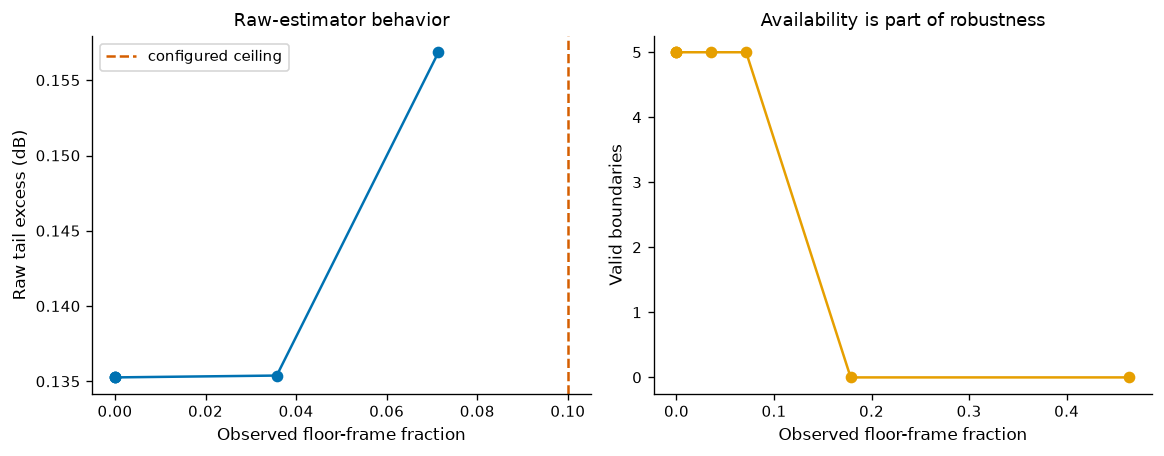

,layer,check,passed,observed,required,action_if_failed,blocking
0,floor,clean synthetic boundaries remain available,True,measured,measured,repair floor eligibility,True
1,floor,floor mixtures above ceiling are unavailable,True,checked,all unavailable,repair digital-floor censoring,True


In [5]:
floor_rows = []
for fraction in [0.0, 0.02, 0.05, 0.10, 0.15, 0.25, 0.50]:
    waveform = base_waveform.copy()
    boundaries = internal_pause_boundaries(
        synthetic_intervals, len(waveform)/FS
    )
    for boundary in boundaries:
        floor_left = round(
            (boundary["speech_offset_sec"]
             + PARAMETERS.floor_start_ms/1000)*FS
        )
        floor_right = round(
            (boundary["speech_offset_sec"]
             + PARAMETERS.floor_end_ms/1000)*FS
        )
        width = max(0, floor_right-floor_left)
        zero_width = round(fraction*width)
        waveform[floor_left:floor_left+zero_width] = 0.0
    extraction = extract_qrev(
        waveform, FS,
        strict_speech=synthetic_intervals,
        logical_recording_id=f"floor_{fraction}",
        compute_srmr=False,
    )
    ledger = extraction.boundary_ledger
    floor_rows.append({
        "injected_floor_window_fraction": fraction,
        "median_observed_floor_frame_fraction": (
            float(ledger["floor_frame_fraction"].median())
            if len(ledger) else np.nan
        ),
        "tail_valid_boundary_count": extraction.recording[
            "qrev_tail_valid_boundary_count"
        ],
        "tail_status": extraction.recording[
            "qrev_tail_excess_100ms_db_status"
        ],
        "tail_raw_estimate": extraction.recording[
            "qrev_tail_excess_100ms_db_raw_estimate"
        ],
        "tail_published": extraction.recording[
            "qrev_tail_excess_100ms_db"
        ],
    })
floor_calibration = pd.DataFrame(floor_rows)
above = floor_calibration[
    "median_observed_floor_frame_fraction"
] > PARAMETERS.maximum_floor_frame_fraction
floor_checks = validation_frame([
    ValidationCheck(
        "floor", "clean synthetic boundaries remain available",
        floor_calibration.iloc[0]["tail_status"] == "measured",
        str(floor_calibration.iloc[0]["tail_status"]),
        "measured",
        "repair floor eligibility",
    ),
    ValidationCheck(
        "floor", "floor mixtures above ceiling are unavailable",
        floor_calibration.loc[above, "tail_published"].isna().all(),
        "checked",
        "all unavailable",
        "repair digital-floor censoring",
    ),
])
save_table_bundle(
    floor_calibration, TABLES, "qrev_v311_floor_censoring_calibration"
)
save_table_bundle(floor_checks, TABLES, "qrev_v311_floor_checks")

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.9))
axes[0].plot(
    floor_calibration["median_observed_floor_frame_fraction"],
    floor_calibration["tail_raw_estimate"],
    "o-", color=OKABE_ITO["blue"],
)
axes[0].axvline(
    PARAMETERS.maximum_floor_frame_fraction,
    color=OKABE_ITO["vermillion"], linestyle="--",
    label="configured ceiling",
)
axes[0].set(
    xlabel="Observed floor-frame fraction",
    ylabel="Raw tail excess (dB)",
    title="Raw-estimator behavior",
)
axes[0].legend()
axes[1].plot(
    floor_calibration["median_observed_floor_frame_fraction"],
    floor_calibration["tail_valid_boundary_count"],
    "o-", color=OKABE_ITO["orange"],
)
axes[1].set(
    xlabel="Observed floor-frame fraction",
    ylabel="Valid boundaries",
    title="Availability is part of robustness",
)
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qrev_floor_censoring_calibration",
    caption=(
        "QREV v3.1 digital-floor calibration. Raw tail behavior and "
        "boundary availability are shown as the late-floor window is "
        "progressively replaced by exact digital zeros."
    ),
    alt_text=(
        "Raw tail estimate and valid-boundary count across increasing "
        "digital-floor contamination."
    ),
)
plt.show()
display(floor_checks)


## 5. Frozen input and provenance contract


In [6]:
def _table_file(stem: Path) -> Path:
    if stem.suffix.lower() in {".csv", ".parquet"} and stem.exists():
        return stem
    for suffix in [".parquet", ".csv"]:
        candidate = stem.with_suffix(suffix)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Missing table: {stem}")


def read_table(stem: Path) -> pd.DataFrame:
    path = _table_file(stem)
    return (
        pd.read_parquet(path)
        if path.suffix.lower() == ".parquet"
        else pd.read_csv(path)
    )


def as_bool(series: pd.Series) -> pd.Series:
    return series.map(
        lambda value: (
            value
            if isinstance(value, bool)
            else str(value).strip().lower() in {"1", "true", "yes", "y"}
        )
    )


def discover_interval_table(folder: Path):
    candidates, seen = [], set()
    for path in sorted(folder.rglob("*")):
        if path.suffix.lower() not in {".csv", ".parquet"}:
            continue
        stem = path.with_suffix("")
        if stem in seen and path.suffix.lower() == ".csv":
            continue
        seen.add(stem)
        try:
            frame = read_table(path)
        except Exception:
            continue
        columns = set(frame.columns)
        if not (
            {"start_sec", "end_sec"}.issubset(columns)
            or {"start", "end"}.issubset(columns)
        ):
            continue
        if not {
            "view", "segment_type", "label", "region"
        }.intersection(columns):
            continue
        if not {
            "logical_recording_id", "file_name"
        }.intersection(columns):
            continue
        score = (
            8*("frozen" in path.stem.lower())
            + 6*("interval" in path.stem.lower())
            + 2*(path.suffix.lower() == ".parquet")
        )
        candidates.append((score, path, frame))
    if not candidates:
        raise FileNotFoundError(
            f"No frozen interval table under {folder}"
        )
    candidates.sort(key=lambda item: (-item[0], str(item[1])))
    if (
        len(candidates) > 1
        and candidates[0][0] == candidates[1][0]
    ):
        raise RuntimeError(
            "Tied interval-table candidates; resolve upstream."
        )
    return candidates[0][1], candidates[0][2]


def load_frozen_inputs():
    cfg = yaml.safe_load(CONFIG.read_text(encoding="utf-8"))
    segmentation_version = str(
        cfg.get("segmentation_freeze", {}).get(
            "version",
            cfg.get("data_freeze", {}).get("version", "v1"),
        )
    )
    data_version = str(
        cfg.get("data_freeze", {}).get("version", "v1")
    )
    segmentation_folder = (
        MAIN_OUTPUTS / "01_SEGMENTATION_FREEZE"
        / segmentation_version
    )
    data_folder = MAIN_OUTPUTS / "00_DATA_FREEZE" / data_version
    decisions_path = _table_file(
        segmentation_folder / "frozen_segmentation_decisions"
    )
    recordings_path = _table_file(
        data_folder / "frozen_bamboo_recordings"
    )
    intervals_path, intervals = discover_interval_table(
        segmentation_folder
    )
    decisions = read_table(decisions_path)
    recordings = read_table(recordings_path)
    if "segmentation_analysis_eligible" not in decisions:
        raise ValueError(
            "Frozen decisions lack segmentation_analysis_eligible"
        )
    eligible = decisions.loc[
        as_bool(decisions["segmentation_analysis_eligible"])
    ].copy()
    if "logical_recording_id" not in intervals:
        mapping = decisions[
            ["file_name", "logical_recording_id"]
        ].drop_duplicates()
        if mapping["file_name"].duplicated().any():
            raise ValueError(
                "file_name is not unique in frozen decisions"
            )
        intervals = intervals.merge(
            mapping,
            on="file_name",
            how="left",
            validate="many_to_one",
        )
    for frame in [eligible, recordings, intervals]:
        frame["logical_recording_id"] = frame[
            "logical_recording_id"
        ].astype(str)
    media_column = next(
        (
            column
            for column in [
                "media_path", "selected_media_path",
                "file_path", "selected_path",
            ]
            if column in recordings
        ),
        None,
    )
    if media_column is None:
        raise ValueError(
            "Frozen recording table lacks selected media path"
        )
    recordings = recordings.rename(
        columns={media_column: "media_path"}
    )
    analysis_recordings = eligible[
        ["logical_recording_id"]
    ].merge(
        recordings.drop_duplicates("logical_recording_id"),
        on="logical_recording_id",
        how="left",
        validate="one_to_one",
    )
    intervals = intervals.rename(
        columns={"start": "start_sec", "end": "end_sec"}
    )
    view_column = next(
        (
            column
            for column in [
                "view", "segment_type", "label", "region",
            ]
            if column in intervals
        ),
        None,
    )
    intervals = intervals.rename(columns={view_column: "view"})
    if (
        "profile" in intervals
        and intervals["profile"].astype(str).eq("primary").any()
    ):
        intervals = intervals.loc[
            intervals["profile"].astype(str).eq("primary")
        ].copy()
    available = sorted(
        intervals["view"].dropna().astype(str).unique()
    )
    strict = next(
        (
            name
            for name in [
                "strict_speech", "primary_speech",
                "final_speech", "speech",
            ]
            if name in available
        ),
        None,
    )
    checks = validation_frame([
        ValidationCheck(
            "input", "one eligible row per recording",
            not analysis_recordings[
                "logical_recording_id"
            ].duplicated().any(),
            str(len(analysis_recordings)),
            "unique IDs",
            "repair data freeze",
        ),
        ValidationCheck(
            "input", "media path complete",
            analysis_recordings["media_path"].notna().all(),
            str(int(
                analysis_recordings["media_path"].isna().sum()
            )),
            "0 missing",
            "repair data freeze",
        ),
        ValidationCheck(
            "input", "strict-speech view available",
            strict is not None,
            str(strict),
            "available",
            "repair segmentation export",
        ),
    ])
    provenance = pd.DataFrame([
        {
            "artifact": "frozen decisions",
            "path": str(decisions_path),
            "sha256": sha256_file(decisions_path),
        },
        {
            "artifact": "frozen recordings",
            "path": str(recordings_path),
            "sha256": sha256_file(recordings_path),
        },
        {
            "artifact": "frozen intervals",
            "path": str(intervals_path),
            "sha256": sha256_file(intervals_path),
        },
        {
            "artifact": "qrev implementation",
            "path": str(ROOT / "src/paper1_qc/qrev.py"),
            "sha256": sha256_file(
                ROOT / "src/paper1_qc/qrev.py"
            ),
        },
        {
            "artifact": "vendored SRMRpy",
            "path": str(
                ROOT / "src/paper1_qc/_vendor/srmrpy/srmr.py"
            ),
            "sha256": sha256_file(
                ROOT / "src/paper1_qc/_vendor/srmrpy/srmr.py"
            ),
        },
    ])
    return {
        "recordings": analysis_recordings,
        "intervals": intervals,
        "strict_speech_view": strict,
        "checks": checks,
        "provenance": provenance,
    }


if RUN_COHORT_EXTRACTION:
    frozen = load_frozen_inputs()
    input_checks = frozen["checks"]
    if not gate_passed(input_checks):
        display(input_checks)
        raise RuntimeError("Frozen input contract failed.")
    save_table_bundle(
        input_checks, TABLES, "qrev_v311_input_contract"
    )
    save_table_bundle(
        frozen["provenance"],
        TABLES,
        "qrev_v311_input_provenance",
    )
else:
    frozen = None
    input_checks = validation_frame([
        ValidationCheck(
            "input", "frozen cohort loaded",
            False, "NOT RUN", "completed",
            "enable cohort extraction",
        )
    ])
display(input_checks)


,layer,check,passed,observed,required,action_if_failed,blocking
0,input,one eligible row per recording,True,519,unique IDs,repair data freeze,True
1,input,media path complete,True,0,0 missing,repair data freeze,True
2,input,strict-speech view available,True,strict_speech,available,repair segmentation export,True


## 6. Memory-safe frozen-cohort extraction and reconstructable ledger

Recordings are decoded and analyzed one at a time. Each recording row and
compact boundary ledger are atomically checkpointed before the waveform is
released. No waveform collection and no full frame ledger are held in
memory. The SRMR memory preflight marks a recording unavailable rather than
truncating it or risking a process crash.


In [7]:
def intervals_for(recording_id: str):
    local = frozen["intervals"].loc[
        frozen["intervals"]["logical_recording_id"].eq(
            str(recording_id)
        )
        & frozen["intervals"]["view"].astype(str).eq(
            str(frozen["strict_speech_view"])
        )
    ].sort_values(["start_sec", "end_sec"])
    return [
        TimeInterval(float(row.start_sec), float(row.end_sec))
        for row in local.itertuples(index=False)
    ]


def media_path_for(row):
    path = Path(str(row.media_path))
    return path if path.is_absolute() else ROOT / path


def checkpoint_paths(recording_id):
    safe = "".join(
        character if character.isalnum() or character in "-_"
        else "_"
        for character in str(recording_id)
    )
    return (
        CHECKPOINTS / f"{safe}.recording.parquet",
        CHECKPOINTS / f"{safe}.boundaries.parquet",
    )


recording_table = pd.DataFrame()
boundary_ledger = pd.DataFrame()
analysis_feature_table = pd.DataFrame()
extraction_errors = pd.DataFrame(
    columns=["logical_recording_id", "error_type", "message"]
)
if RUN_COHORT_EXTRACTION:
    checkpoint_signature_payload = {
        "measurement_version": MEASUREMENT_VERSION,
        "implementation_sha256": sha256_file(
            ROOT / "src/paper1_qc/qrev.py"
        ),
        "vendored_srmrpy_sha256": sha256_file(
            ROOT / "src/paper1_qc/_vendor/srmrpy/srmr.py"
        ),
        "parameters": PARAMETERS.to_dict(),
        "input_sha256": frozen["provenance"][
            ["artifact", "sha256"]
        ].to_dict(orient="records"),
    }
    checkpoint_signature = hashlib.sha256(
        json.dumps(
            checkpoint_signature_payload,
            sort_keys=True,
        ).encode("utf-8")
    ).hexdigest()
    ffmpeg, ffprobe = shutil.which("ffmpeg"), shutil.which("ffprobe")
    if not ffmpeg or not ffprobe:
        raise RuntimeError(
            "ffmpeg and ffprobe are required for cohort extraction"
        )
    error_rows = []
    expected_checkpoint_rows = []
    for row in frozen["recordings"].itertuples(index=False):
        recording_id = str(row.logical_recording_id)
        recording_checkpoint, boundary_checkpoint = checkpoint_paths(
            recording_id
        )
        expected_checkpoint_rows.append({
            "logical_recording_id": recording_id,
            "recording_checkpoint": str(recording_checkpoint),
            "boundary_checkpoint": str(boundary_checkpoint),
        })
        resume_valid = False
        if (
            RESUME_FROM_CHECKPOINTS
            and recording_checkpoint.exists()
            and boundary_checkpoint.exists()
        ):
            try:
                prior = pd.read_parquet(
                    recording_checkpoint,
                    columns=["qrev_checkpoint_signature"],
                )
                resume_valid = bool(
                    len(prior) == 1
                    and prior[
                        "qrev_checkpoint_signature"
                    ].iloc[0] == checkpoint_signature
                )
            except Exception:
                resume_valid = False
        if resume_valid:
            continue
        views = None
        extraction = None
        try:
            views = decode_audio_views(
                media_path_for(row),
                ffmpeg=ffmpeg,
                ffprobe=ffprobe,
                analysis_rate=FS,
            )
            extraction = extract_qrev(
                views.analysis_16k,
                FS,
                strict_speech=intervals_for(recording_id),
                logical_recording_id=recording_id,
                compute_srmr=True,
            )
            recording_row = {
                **extraction.recording,
                "qrev_checkpoint_signature": checkpoint_signature,
                "file_name": getattr(
                    row, "file_name", media_path_for(row).name
                ),
                "media_path": str(media_path_for(row)),
                "native_sample_rate_hz": views.sample_rate_native,
                "native_channels": (
                    views.native.shape[1]
                    if views.native.ndim == 2 else 1
                ),
                "codec_name": views.probe.get("codec_name"),
            }
            recording_tmp = recording_checkpoint.with_name(
                f".{recording_checkpoint.name}.tmp"
            )
            boundary_tmp = boundary_checkpoint.with_name(
                f".{boundary_checkpoint.name}.tmp"
            )
            pd.DataFrame([recording_row]).to_parquet(
                recording_tmp, index=False
            )
            extraction.boundary_ledger.to_parquet(
                boundary_tmp, index=False
            )
            recording_tmp.replace(recording_checkpoint)
            boundary_tmp.replace(boundary_checkpoint)
        except Exception as exc:
            error_rows.append({
                "logical_recording_id": recording_id,
                "error_type": type(exc).__name__,
                "message": str(exc),
            })
        finally:
            views = None
            extraction = None
            gc.collect()

    checkpoint_index = pd.DataFrame(expected_checkpoint_rows)
    completed = checkpoint_index.loc[
        checkpoint_index["recording_checkpoint"].map(
            lambda path: Path(path).exists()
        )
        & checkpoint_index["boundary_checkpoint"].map(
            lambda path: Path(path).exists()
        )
    ]
    recording_parts = [
        pd.read_parquet(path)
        for path in completed["recording_checkpoint"]
    ]
    boundary_parts = [
        pd.read_parquet(path)
        for path in completed["boundary_checkpoint"]
    ]
    recording_table = (
        pd.concat(recording_parts, ignore_index=True)
        if recording_parts else pd.DataFrame()
    )
    boundary_ledger = (
        pd.concat(boundary_parts, ignore_index=True)
        if boundary_parts else pd.DataFrame()
    )
    extraction_errors = pd.DataFrame(
        error_rows,
        columns=[
            "logical_recording_id", "error_type", "message",
        ],
    )
    save_table_bundle(
        recording_table, TABLES, "qrev_v311_recording_features"
    )
    save_table_bundle(
        boundary_ledger, TABLES, "qrev_v311_boundary_ledger"
    )
    save_table_bundle(
        extraction_errors, TABLES, "qrev_v311_extraction_errors"
    )
    save_table_bundle(
        checkpoint_index, AUDIT, "qrev_v311_checkpoint_index"
    )

    analysis_columns = [
        "logical_recording_id",
        "qrev_measurement_version",
        "qrev_signal_view",
        "qrev_speech_source",
        "qrev_internal_boundary_count",
        "qrev_tail_valid_boundary_count",
        "qrev_tail_valid_pause_support_sec",
        "qrev_persistence_valid_boundary_count",
        "qrev_persistence_observation_support_sec",
        "qrev_persistence_right_censored_fraction",
        "qrev_persistence_recording_median_censored",
        "qrev_decay_valid_boundary_count",
        "qrev_nondecreasing_decay_boundary_fraction",
        "qrev_floor_unstable_boundary_fraction",
        "qrev_srmr_variant",
        "qrev_srmr_upstream_commit",
        "qrev_srmr_task_span_sec",
        "qrev_srmr_strict_speech_support_sec",
        "qrev_srmr_estimated_working_set_mb",
        *ANALYSIS_FEATURES,
        *[
            column
            for feature in ANALYSIS_FEATURES
            for column in (
                f"{feature}_support_tier",
                f"{feature}_status",
            )
        ],
        "qrev_primary_available_count",
        "qrev_primary_analysis_eligible",
        "qrev_family_status",
    ]
    analysis_feature_table = recording_table.loc[
        :, analysis_columns
    ].copy()
    save_table_bundle(
        analysis_feature_table,
        TABLES,
        "qrev_v311_analysis_features",
    )

    expected_ids = set(
        frozen["recordings"]["logical_recording_id"].astype(str)
    )
    observed_ids = set(
        recording_table["logical_recording_id"].astype(str)
    )
    coverage = len(expected_ids & observed_ids)/max(1, len(expected_ids))
    value_status_agreement = True
    for feature in ANALYSIS_FEATURES:
        finite = np.isfinite(
            pd.to_numeric(recording_table[feature], errors="coerce")
        )
        status = recording_table[f"{feature}_status"].astype(str)
        permitted_finite = status.isin([
            "measured", "right_censored_at_horizon",
        ])
        value_status_agreement &= bool(finite.eq(permitted_finite).all())
    reconstruction_ok = True
    if len(boundary_ledger):
        for row in recording_table.itertuples(index=False):
            local = boundary_ledger.loc[
                boundary_ledger["logical_recording_id"].eq(
                    str(row.logical_recording_id)
                )
            ]
            valid = local.loc[local["tail_eligible"].astype(bool)]
            observed = getattr(row, "qrev_tail_excess_100ms_db")
            if np.isfinite(observed):
                reconstruction_ok &= bool(np.isclose(
                    np.median(valid["tail_excess_100ms_db"]),
                    observed,
                    atol=1e-12,
                ))
    extraction_checks = validation_frame([
        ValidationCheck(
            "extraction", "eligible-ID coverage",
            coverage >= 0.99,
            f"{coverage:.2%}",
            ">=99%",
            "resolve extraction failures",
        ),
        ValidationCheck(
            "extraction", "one output row per ID",
            not recording_table[
                "logical_recording_id"
            ].duplicated().any(),
            str(recording_table[
                "logical_recording_id"
            ].duplicated().sum()),
            "0 duplicates",
            "repair identity mapping",
        ),
        ValidationCheck(
            "extraction", "status/value agreement",
            value_status_agreement,
            str(value_status_agreement),
            "exact",
            "repair support/status logic",
        ),
        ValidationCheck(
            "extraction", "boundary ledger reconstructs tail estimator",
            reconstruction_ok,
            str(reconstruction_ok),
            "exact",
            "repair ledger or aggregation",
        ),
        ValidationCheck(
            "extraction", "no scalar QREV score",
            not any(
                column in recording_table
                for column in [
                    "qrev_score", "qrev_composite", "qrev_burden",
                ]
            ),
            "absent",
            "absent",
            "remove composite",
        ),
        ValidationCheck(
            "extraction", "SRMR dependency/runtime available",
            not recording_table[
                "qrev_srmr_norm_status"
            ].isin([
                "dependency_unavailable", "computation_failed",
            ]).any(),
            "checked",
            "no dependency/computation failure",
            "restore pinned reverb environment",
        ),
    ])
else:
    extraction_checks = validation_frame([
        ValidationCheck(
            "extraction", "full cohort extraction",
            False, "NOT RUN", "completed",
            "enable cohort extraction",
        )
    ])
display(extraction_checks)
if len(extraction_errors):
    display(extraction_errors)


,layer,check,passed,observed,required,action_if_failed,blocking
0,extraction,eligible-ID coverage,True,100.00%,>=99%,resolve extraction failures,True
1,extraction,one output row per ID,True,0,0 duplicates,repair identity mapping,True
2,extraction,status/value agreement,True,True,exact,repair support/status logic,True
3,extraction,boundary ledger reconstructs tail estimator,True,True,exact,repair ledger or aggregation,True
4,extraction,no scalar QREV score,True,absent,absent,remove composite,True
5,extraction,SRMR dependency/runtime available,True,checked,no dependency/computation failure,restore pinned reverb environment,True


## 7. Codec and resampling stability


In [8]:
codec_results = pd.DataFrame()
if RUN_CODEC_ROUNDTRIP and shutil.which("ffmpeg") and shutil.which("ffprobe"):
    with TemporaryDirectory() as temporary:
        temporary = Path(temporary)
        source_wav = temporary / "qrev_source.wav"
        sf.write(source_wav, base_waveform, FS, subtype="PCM_24")
        conditions = [("pcm24", source_wav)]
        commands = [
            (
                "opus_48k_64k",
                temporary / "qrev_opus.ogg",
                [
                    "-c:a", "libopus", "-b:a", "64k",
                    "-ar", "48000",
                ],
            ),
            (
                "aac_44k1_96k",
                temporary / "qrev_aac.m4a",
                [
                    "-c:a", "aac", "-b:a", "96k",
                    "-ar", "44100",
                ],
            ),
        ]
        for name, output, options in commands:
            completed = subprocess.run(
                [
                    shutil.which("ffmpeg"), "-nostdin", "-y",
                    "-v", "error", "-i", str(source_wav),
                    *options, str(output),
                ],
                capture_output=True,
                text=True,
            )
            if completed.returncode != 0:
                raise RuntimeError(
                    f"Codec control failed for {name}: "
                    f"{completed.stderr}"
                )
            conditions.append((name, output))

        rows = []
        for name, path in conditions:
            views = decode_audio_views(
                path,
                ffmpeg=shutil.which("ffmpeg"),
                ffprobe=shutil.which("ffprobe"),
                analysis_rate=FS,
            )
            result = extract_qrev(
                views.analysis_16k,
                FS,
                strict_speech=synthetic_intervals,
                logical_recording_id=name,
                compute_srmr=True,
            ).recording
            rows.append({
                "condition": name,
                **{feature: result[feature] for feature in ANALYSIS_FEATURES},
            })
            del views
            gc.collect()
        codec_results = pd.DataFrame(rows)
    reference = codec_results.set_index("condition").loc["pcm24"]
    for feature in ANALYSIS_FEATURES:
        codec_results[f"{feature}_absolute_delta"] = (
            codec_results[feature]-reference[feature]
        ).abs()
    nonreference = codec_results.loc[
        ~codec_results["condition"].eq("pcm24")
    ]
    codec_checks = validation_frame([
        ValidationCheck(
            "codec", "tail excess codec delta",
            nonreference[
                "qrev_tail_excess_100ms_db_absolute_delta"
            ].max() <= 3.0,
            f"{nonreference['qrev_tail_excess_100ms_db_absolute_delta'].max():.3f} dB",
            "<=3 dB",
            "qualify codec sensitivity or revise estimator",
        ),
        ValidationCheck(
            "codec", "persistence codec delta",
            nonreference[
                "qrev_tail_persistence_median_sec_absolute_delta"
            ].max() <= 0.08,
            f"{nonreference['qrev_tail_persistence_median_sec_absolute_delta'].max():.3f} s",
            "<=0.08 s",
            "qualify codec sensitivity or revise estimator",
        ),
        ValidationCheck(
            "codec", "normalized SRMR relative codec delta",
            (
                nonreference[
                    "qrev_srmr_norm_absolute_delta"
                ].max()/max(reference["qrev_srmr_norm"], 1e-12)
            ) <= 0.25,
            "checked",
            "<=25%",
            "qualify codec dependence",
        ),
    ])
else:
    codec_checks = validation_frame([
        ValidationCheck(
            "codec", "codec/resampling control completed",
            False,
            "NOT RUN",
            "completed",
            "install ffmpeg and enable control",
        )
    ])
save_table_bundle(
    codec_results, TABLES, "qrev_v311_codec_roundtrip"
)
save_table_bundle(codec_checks, TABLES, "qrev_v311_codec_checks")
display(codec_results)
display(codec_checks)


,condition,qrev_tail_excess_100ms_db,qrev_tail_persistence_median_sec,qrev_downward_decay_rate_db_per_sec,qrev_srmr_norm,qrev_tail_excess_100ms_db_absolute_delta,qrev_tail_persistence_median_sec_absolute_delta,qrev_downward_decay_rate_db_per_sec_absolute_delta,qrev_srmr_norm_absolute_delta
0,pcm24,0.135028,0.015,NaN,2.336189,0.000000,0.00,NaN,0.000000
1,opus_48k_64k,2.604261,0.045,10.549406,2.343637,2.469234,0.03,NaN,0.007448
2,aac_44k1_96k,0.185358,0.045,NaN,2.345833,0.050330,0.03,NaN,0.009644


,layer,check,passed,observed,required,action_if_failed,blocking
0,codec,tail excess codec delta,True,2.469 dB,<=3 dB,qualify codec sensitivity or revise estimator,True
1,codec,persistence codec delta,True,0.030 s,<=0.08 s,qualify codec sensitivity or revise estimator,True
2,codec,normalized SRMR relative codec delta,True,checked,<=25%,qualify codec dependence,True


## 8. Boundary, window, support, and availability robustness

The primary segmentation sensitivity grid shifts frozen speech offsets
without moving the next speech onset. The window grid changes early and
late-floor definitions. A shorter 900-ms support condition jointly moves the
late-floor window to 600–900 ms; this is required because a persistence
horizon cannot end before the floor used to define return-to-baseline. All
variants rerun the full boundary estimator, and availability transitions are
reported alongside numerical deltas.

The validation sample is deterministically stratified across baseline support
and feature magnitude rather than taking the first sorted files.
Delete-one-boundary analysis includes the minimum valid support tier and tests
recording-level aggregation without re-decoding audio.

Numerical stability and measurement availability are distinct properties.
The two primary conditional features must retain at least 90% availability
under ±20-ms offset perturbations. The secondary conditional decay descriptor
is instead required to retain adequate paired support and rank ordering,
because entering or leaving the valid-negative-slope subset is part of its
declared estimand. Its availability retention and numerical changes remain
mandatory reported diagnostics and it is not promoted to a primary endpoint.

The original 3-dB tail-change rule is retained as a descriptive diagnostic.
The blocking magnitude criterion is the empirical interquartile range of the
baseline tail feature, because QREV is an uncalibrated relative descriptor and
no validated universal 3-dB acceptability threshold exists for this estimator.


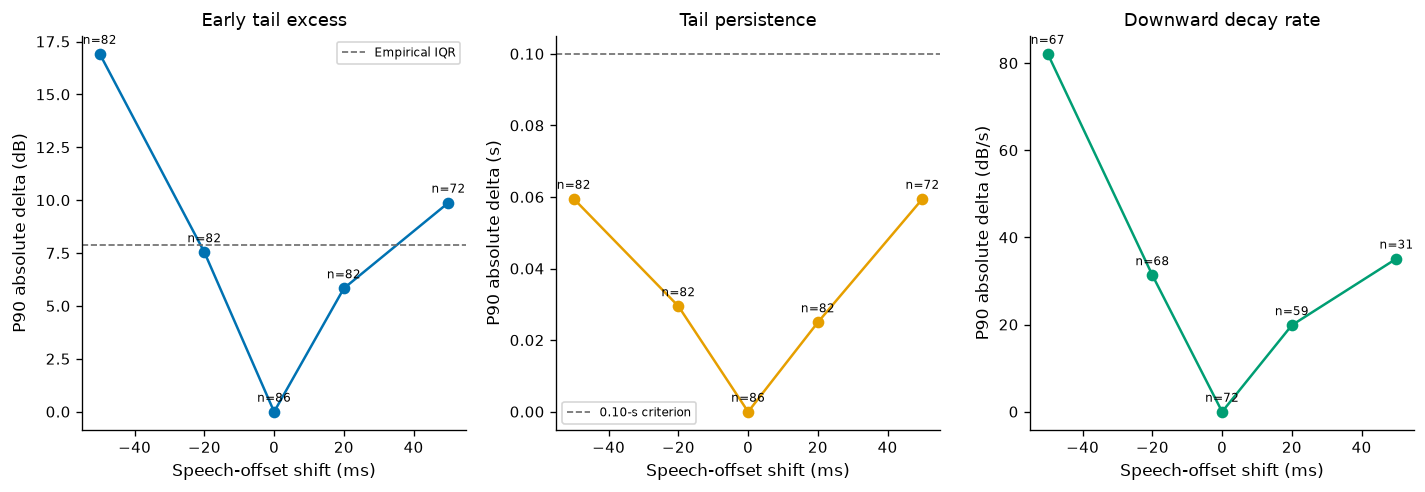

,layer,check,passed,observed,required,action_if_failed,blocking
0,robustness,tail paired support at +/-20 ms,True,"{-20: 82, 20: 82}",>=30 each,increase stratified validation sample,True
1,robustness,tail rank stability at +/-20 ms,True,checked,rho>=0.80,revise offset robustness or claims,True
2,robustness,tail p90 delta within empirical IQR at +/-20 ms,True,"{-20: 7.541, 20: 5.835}",<=7.905 dB,revise boundary estimator,True
3,robustness,descriptive 3-dB tail diagnostic at +/-20 ms,True,"{-20: 7.541, 20: 5.835}",reported; not a blocking threshold,qualify observed sensitivity,True
4,robustness,persistence p90 delta at +/-20 ms,True,checked,<=0.10 s,revise persistence estimator,True
5,robustness,primary-feature availability retained at +/-20 ms,True,"{'qrev_tail_excess_100ms_db': 0.953, 'qrev_tai...",>=0.90 for both primary conditional features,revise primary estimator or support policy,True
6,robustness,secondary decay remains estimable and rank-stable,True,"{""minimum_availability_retention"": 0.819, ""min...",paired_n>=30 and rho>=0.80; availability repor...,retain as secondary only or remove from analys...,True
7,robustness,alternative-window paired support complete,True,"{'qrev_downward_decay_rate_db_per_sec': 67, 'q...",>=30 for all 3 features x 6 windows,revise infeasible window or sample design,True
8,robustness,alternative-window rank stability,True,checked,rho>=0.70 for every feature-window pair,revisit window choice,True
9,robustness,minimum-support delete-one coverage complete,True,40/40,all minimum-support tail records represented,increase support sample or inspect ledger,True


In [9]:
robustness_rows = []
window_rows = []
deletion_rows = []
robustness_sample = pd.DataFrame()


def shifted_offsets(intervals, shift_ms):
    delta = float(shift_ms)/1000
    output = []
    for index, item in enumerate(intervals):
        ceiling = (
            intervals[index+1].start_sec
            - PARAMETERS.frame_length_ms/1000
            if index < len(intervals)-1
            else item.end_sec+max(delta, 0)
        )
        end = min(item.end_sec+delta, ceiling)
        end = max(item.start_sec+0.05, end)
        output.append(TimeInterval(item.start_sec, end))
    return output


def deterministic_stratified_sample(
    frame,
    maximum_rows,
    stratum_columns,
):
    # Select a reproducible, round-robin sample across strata.

    local = frame.copy()
    if len(local) <= maximum_rows:
        return local.sort_values("logical_recording_id")
    local["_stable_order"] = local[
        "logical_recording_id"
    ].astype(str).map(
        lambda value: hashlib.sha256(
            f"{PARAMETERS.random_seed}|{value}".encode("utf-8")
        ).hexdigest()
    )
    groups = [
        group.sort_values("_stable_order").reset_index(drop=True)
        for _, group in local.groupby(
            stratum_columns, dropna=False, sort=True
        )
    ]
    selected = []
    row_index = 0
    while len(selected) < maximum_rows:
        added = False
        for group in groups:
            if row_index < len(group):
                selected.append(group.iloc[row_index])
                added = True
                if len(selected) == maximum_rows:
                    break
        if not added:
            break
        row_index += 1
    return pd.DataFrame(selected).drop(
        columns="_stable_order", errors="ignore"
    )


if RUN_COHORT_EXTRACTION and len(recording_table):
    available_pool = recording_table.loc[
        pd.to_numeric(
            recording_table["qrev_tail_excess_100ms_db"],
            errors="coerce",
        ).notna()
    ].copy()
    if len(available_pool):
        available_pool["tail_magnitude_quintile"] = pd.qcut(
            available_pool[
                "qrev_tail_excess_100ms_db"
            ].rank(method="first"),
            q=min(5, len(available_pool)),
            labels=False,
            duplicates="drop",
        )
    else:
        available_pool["tail_magnitude_quintile"] = pd.Series(
            dtype="Int64"
        )
    available_pool["validation_population"] = (
        "baseline_tail_available"
    )
    unavailable_pool = recording_table.loc[
        ~recording_table["logical_recording_id"].isin(
            available_pool["logical_recording_id"]
        )
    ].copy()
    if len(unavailable_pool):
        unavailable_pool["boundary_support_quartile"] = pd.qcut(
            unavailable_pool[
                "qrev_internal_boundary_count"
            ].rank(method="first"),
            q=min(4, len(unavailable_pool)),
            labels=False,
            duplicates="drop",
        )
    else:
        unavailable_pool["boundary_support_quartile"] = pd.Series(
            dtype="Int64"
        )
    unavailable_pool["validation_population"] = (
        "baseline_tail_unavailable"
    )

    available_sample = deterministic_stratified_sample(
        available_pool,
        MAX_ROBUSTNESS_AVAILABLE_RECORDINGS,
        [
            "qrev_tail_excess_100ms_db_support_tier",
            "tail_magnitude_quintile",
        ],
    )
    unavailable_sample = deterministic_stratified_sample(
        unavailable_pool,
        MAX_ROBUSTNESS_UNAVAILABLE_RECORDINGS,
        ["boundary_support_quartile"],
    )
    robustness_sample = pd.concat(
        [available_sample, unavailable_sample],
        ignore_index=True,
    )
    sample_population = (
        robustness_sample.set_index("logical_recording_id")[
            "validation_population"
        ].astype(str).to_dict()
    )
    sample_ids = (
        robustness_sample["logical_recording_id"]
        .astype(str)
        .drop_duplicates()
        .tolist()
    )
    row_index = frozen["recordings"].set_index(
        "logical_recording_id"
    )
    for recording_id in sample_ids:
        row = row_index.loc[recording_id]
        views = decode_audio_views(
            media_path_for(row),
            ffmpeg=shutil.which("ffmpeg"),
            ffprobe=shutil.which("ffprobe"),
            analysis_rate=FS,
        )
        original_intervals = intervals_for(recording_id)
        for shift_ms in [-50, -20, 0, 20, 50]:
            result = extract_qrev(
                views.analysis_16k,
                FS,
                strict_speech=shifted_offsets(
                    original_intervals, shift_ms
                ),
                logical_recording_id=recording_id,
                compute_srmr=False,
            ).recording
            robustness_rows.append({
                "logical_recording_id": recording_id,
                "validation_population": sample_population[
                    recording_id
                ],
                "offset_shift_ms": shift_ms,
                **{
                    feature: result[feature]
                    for feature in ANALYSIS_FEATURES[:3]
                },
                "tail_available": np.isfinite(
                    result["qrev_tail_excess_100ms_db"]
                ),
                "persistence_available": np.isfinite(
                    result["qrev_tail_persistence_median_sec"]
                ),
                "decay_available": np.isfinite(
                    result[
                        "qrev_downward_decay_rate_db_per_sec"
                    ]
                ),
            })
        variants = {
            "baseline": PARAMETERS,
            "early_80ms": replace(
                PARAMETERS, early_tail_end_ms=80.0
            ),
            "early_120ms": replace(
                PARAMETERS, early_tail_end_ms=120.0
            ),
            "floor_600_900ms": replace(
                PARAMETERS, floor_start_ms=600.0,
                floor_end_ms=900.0,
            ),
            "floor_650_950ms": replace(
                PARAMETERS, floor_start_ms=650.0,
                floor_end_ms=950.0,
            ),
            "short_support_900ms": replace(
                PARAMETERS,
                persistence_horizon_ms=900.0,
                floor_start_ms=600.0,
                floor_end_ms=900.0,
            ),
            "horizon_1200ms": replace(
                PARAMETERS, persistence_horizon_ms=1200.0,
            ),
        }
        for variant_name, variant_parameters in variants.items():
            result = extract_qrev(
                views.analysis_16k,
                FS,
                strict_speech=original_intervals,
                logical_recording_id=recording_id,
                parameters=variant_parameters,
                compute_srmr=False,
            ).recording
            window_rows.append({
                "logical_recording_id": recording_id,
                "validation_population": sample_population[
                    recording_id
                ],
                "variant": variant_name,
                **{
                    feature: result[feature]
                    for feature in ANALYSIS_FEATURES[:3]
                },
                "tail_boundary_count": result[
                    "qrev_tail_valid_boundary_count"
                ],
                "persistence_censored_fraction": result[
                    "qrev_persistence_right_censored_fraction"
                ],
                "tail_available": np.isfinite(
                    result["qrev_tail_excess_100ms_db"]
                ),
                "persistence_available": np.isfinite(
                    result["qrev_tail_persistence_median_sec"]
                ),
                "decay_available": np.isfinite(
                    result[
                        "qrev_downward_decay_rate_db_per_sec"
                    ]
                ),
            })
        del views
        gc.collect()

    robustness_grid = pd.DataFrame(robustness_rows)
    window_grid = pd.DataFrame(window_rows)
    support_tier_lookup = {
        feature: recording_table.set_index(
            "logical_recording_id"
        )[f"{feature}_support_tier"].astype(str).to_dict()
        for feature in CONDITIONAL_BOUNDARY_FEATURES
    }

    for recording_id, local in boundary_ledger.groupby(
        "logical_recording_id", sort=True
    ):
        specifications = [
            (
                "qrev_tail_excess_100ms_db",
                "tail_eligible",
                "tail_excess_100ms_db",
            ),
            (
                "qrev_tail_persistence_median_sec",
                "persistence_eligible",
                "tail_persistence_sec",
            ),
            (
                "qrev_downward_decay_rate_db_per_sec",
                "decay_eligible",
                "downward_decay_rate_db_per_sec",
            ),
        ]
        for feature, flag, column in specifications:
            valid = local.loc[
                local[flag].astype(bool), column
            ].dropna().to_numpy(float)
            if len(valid) < 4:
                continue
            full = float(np.median(valid))
            for omitted in range(len(valid)):
                reduced = float(np.median(np.delete(valid, omitted)))
                deletion_rows.append({
                    "logical_recording_id": recording_id,
                    "feature": feature,
                    "support_tier": support_tier_lookup[
                        feature
                    ].get(str(recording_id), "unavailable"),
                    "boundary_count": len(valid),
                    "full_estimate": full,
                    "delete_one_estimate": reduced,
                    "absolute_delta": abs(reduced-full),
                })
    deletion_grid = pd.DataFrame(deletion_rows)

    def paired_summary(frame, condition_column, baseline_value, feature):
        baseline = frame.loc[
            frame[condition_column].eq(baseline_value),
            ["logical_recording_id", feature],
        ].rename(columns={feature: "baseline"})
        baseline_available_n = int(
            pd.to_numeric(
                baseline["baseline"], errors="coerce"
            ).notna().sum()
        )
        rows = []
        for condition, local in frame.groupby(
            condition_column, sort=True
        ):
            condition_available_n = int(
                pd.to_numeric(
                    local[feature], errors="coerce"
                ).notna().sum()
            )
            paired = local[
                ["logical_recording_id", feature]
            ].merge(
                baseline,
                on="logical_recording_id",
                how="inner",
            ).dropna()
            rho = (
                float(stats.spearmanr(
                    paired[feature], paired["baseline"]
                ).statistic)
                if len(paired) >= 3
                and paired[feature].nunique() > 1
                and paired["baseline"].nunique() > 1
                else np.nan
            )
            delta = (paired[feature]-paired["baseline"]).abs()
            rows.append({
                condition_column: condition,
                "feature": feature,
                "baseline_available_n": baseline_available_n,
                "condition_available_n": condition_available_n,
                "paired_n": len(paired),
                "paired_fraction_of_baseline": (
                    len(paired)/baseline_available_n
                    if baseline_available_n else np.nan
                ),
                "availability_retention": (
                    len(paired)/baseline_available_n
                    if baseline_available_n else np.nan
                ),
                "spearman_rho": rho,
                "median_absolute_delta": (
                    float(delta.median()) if len(delta) else np.nan
                ),
                "p90_absolute_delta": (
                    float(delta.quantile(0.90))
                    if len(delta) else np.nan
                ),
            })
        return rows

    offset_summary = pd.DataFrame([
        row
        for feature in ANALYSIS_FEATURES[:3]
        for row in paired_summary(
            robustness_grid, "offset_shift_ms", 0, feature
        )
    ])
    window_summary = pd.DataFrame([
        row
        for feature in ANALYSIS_FEATURES[:3]
        for row in paired_summary(
            window_grid, "variant", "baseline", feature
        )
    ])
    delete_summary = (
        deletion_grid.groupby(
            ["feature", "support_tier"], as_index=False,
            dropna=False,
        )
        .agg(
            recordings=("logical_recording_id", "nunique"),
            comparisons=("absolute_delta", "size"),
            median_absolute_delta=("absolute_delta", "median"),
            p90_absolute_delta=(
                "absolute_delta",
                lambda values: values.quantile(0.90),
            ),
        )
        if len(deletion_grid) else pd.DataFrame()
    )

    shift20 = offset_summary.loc[
        offset_summary["offset_shift_ms"].isin([-20, 20])
    ]
    tail_shift = shift20.loc[
        shift20["feature"].eq("qrev_tail_excess_100ms_db")
    ]
    persistence_shift = shift20.loc[
        shift20["feature"].eq(
            "qrev_tail_persistence_median_sec"
        )
    ]
    primary_shift = shift20.loc[
        shift20["feature"].isin(PRIMARY_FEATURES)
    ]
    decay_shift = shift20.loc[
        shift20["feature"].eq(
            "qrev_downward_decay_rate_db_per_sec"
        )
    ]
    alternative_windows = window_summary.loc[
        ~window_summary["variant"].eq("baseline")
    ]
    tail_baseline = pd.to_numeric(
        recording_table["qrev_tail_excess_100ms_db"],
        errors="coerce",
    ).dropna()
    tail_empirical_iqr = float(
        tail_baseline.quantile(0.75)
        - tail_baseline.quantile(0.25)
    )
    minimum_support_ids = set(
        recording_table.loc[
            recording_table[
                "qrev_tail_excess_100ms_db_support_tier"
            ].eq("minimum"),
            "logical_recording_id",
        ].astype(str)
    )
    deletion_minimum_ids = set(
        deletion_grid.loc[
            deletion_grid["feature"].eq(
                "qrev_tail_excess_100ms_db"
            ),
            "logical_recording_id",
        ].astype(str)
    )
    robustness_checks = validation_frame([
        ValidationCheck(
            "robustness",
            "tail paired support at +/-20 ms",
            len(tail_shift) == 2
            and tail_shift["paired_n"].ge(
                MINIMUM_ROBUSTNESS_PAIRED_N
            ).all(),
            str(
                tail_shift.set_index("offset_shift_ms")[
                    "paired_n"
                ].to_dict()
            ),
            f">={MINIMUM_ROBUSTNESS_PAIRED_N} each",
            "increase stratified validation sample",
        ),
        ValidationCheck(
            "robustness", "tail rank stability at +/-20 ms",
            tail_shift["spearman_rho"].notna().all()
            and tail_shift["spearman_rho"].ge(0.80).all()
            and len(tail_shift) == 2,
            "checked",
            "rho>=0.80",
            "revise offset robustness or claims",
        ),
        ValidationCheck(
            "robustness",
            "tail p90 delta within empirical IQR at +/-20 ms",
            tail_shift["p90_absolute_delta"].notna().all()
            and tail_shift["p90_absolute_delta"].le(
                tail_empirical_iqr
            ).all()
            and len(tail_shift) == 2,
            str(
                tail_shift.set_index("offset_shift_ms")[
                    "p90_absolute_delta"
                ].round(3).to_dict()
            ),
            f"<={tail_empirical_iqr:.3f} dB",
            "revise boundary estimator",
        ),
        ValidationCheck(
            "robustness",
            "descriptive 3-dB tail diagnostic at +/-20 ms",
            True,
            str(
                tail_shift.set_index("offset_shift_ms")[
                    "p90_absolute_delta"
                ].round(3).to_dict()
            ),
            "reported; not a blocking threshold",
            "qualify observed sensitivity",
        ),
        ValidationCheck(
            "robustness", "persistence p90 delta at +/-20 ms",
            persistence_shift["p90_absolute_delta"].notna().all()
            and persistence_shift[
                "p90_absolute_delta"
            ].le(0.10).all()
            and len(persistence_shift) == 2,
            "checked",
            "<=0.10 s",
            "revise persistence estimator",
        ),
        ValidationCheck(
            "robustness",
            "primary-feature availability retained at +/-20 ms",
            len(primary_shift) == 4
            and primary_shift[
                "availability_retention"
            ].notna().all()
            and primary_shift[
                "availability_retention"
            ].ge(0.90).all(),
            str(
                primary_shift.groupby("feature")[
                    "availability_retention"
                ].min().round(3).to_dict()
            ),
            ">=0.90 for both primary conditional features",
            "revise primary estimator or support policy",
        ),
        ValidationCheck(
            "robustness",
            "secondary decay remains estimable and rank-stable",
            len(decay_shift) == 2
            and decay_shift["paired_n"].ge(
                MINIMUM_ROBUSTNESS_PAIRED_N
            ).all()
            and decay_shift["spearman_rho"].notna().all()
            and decay_shift["spearman_rho"].ge(0.80).all(),
            json.dumps({
                "paired_n": (
                    decay_shift.set_index("offset_shift_ms")[
                        "paired_n"
                    ].to_dict()
                ),
                "minimum_availability_retention": (
                    round(float(
                        decay_shift[
                            "availability_retention"
                        ].min()
                    ), 3)
                    if len(decay_shift) else None
                ),
                "minimum_spearman_rho": (
                    round(float(
                        decay_shift["spearman_rho"].min()
                    ), 3)
                    if len(decay_shift) else None
                ),
            }, sort_keys=True),
            (
                f"paired_n>={MINIMUM_ROBUSTNESS_PAIRED_N} and "
                "rho>=0.80; availability reported, not promoted "
                "to a primary-feature threshold"
            ),
            "retain as secondary only or remove from analysis table",
        ),
        ValidationCheck(
            "robustness",
            "alternative-window paired support complete",
            len(alternative_windows) == 18
            and alternative_windows["paired_n"].ge(
                MINIMUM_ROBUSTNESS_PAIRED_N
            ).all(),
            str(
                alternative_windows.groupby("feature")[
                    "paired_n"
                ].min().to_dict()
            ),
            (
                f">={MINIMUM_ROBUSTNESS_PAIRED_N} for all "
                "3 features x 6 windows"
            ),
            "revise infeasible window or sample design",
        ),
        ValidationCheck(
            "robustness", "alternative-window rank stability",
            bool(
                len(alternative_windows) == 18
                and alternative_windows[
                    "spearman_rho"
                ].notna().all()
                and alternative_windows[
                    "spearman_rho"
                ].ge(0.70).all()
            ),
            "checked",
            "rho>=0.70 for every feature-window pair",
            "revisit window choice",
        ),
        ValidationCheck(
            "robustness",
            "minimum-support delete-one coverage complete",
            minimum_support_ids.issubset(deletion_minimum_ids),
            (
                f"{len(deletion_minimum_ids & minimum_support_ids)}"
                f"/{len(minimum_support_ids)}"
            ),
            "all minimum-support tail records represented",
            "increase support sample or inspect ledger",
        ),
    ])
else:
    robustness_grid = pd.DataFrame()
    window_grid = pd.DataFrame()
    deletion_grid = pd.DataFrame()
    offset_summary = pd.DataFrame()
    window_summary = pd.DataFrame()
    delete_summary = pd.DataFrame()
    robustness_sample = pd.DataFrame()
    robustness_checks = validation_frame([
        ValidationCheck(
            "robustness", "cohort robustness completed",
            False, "NOT RUN", "completed",
            "enable cohort extraction",
        )
    ])

for frame, stem in [
    (robustness_sample, "qrev_v311_robustness_sample"),
    (robustness_grid, "qrev_v311_offset_sensitivity_grid"),
    (offset_summary, "qrev_v311_offset_sensitivity_summary"),
    (window_grid, "qrev_v311_window_sensitivity_grid"),
    (window_summary, "qrev_v311_window_sensitivity_summary"),
    (deletion_grid, "qrev_v311_delete_one_boundary_grid"),
    (delete_summary, "qrev_v311_delete_one_boundary_summary"),
    (robustness_checks, "qrev_v311_robustness_checks"),
]:
    save_table_bundle(frame, TABLES, stem)

if len(offset_summary):
    fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.2))
    feature_titles = [
        "Early tail excess",
        "Tail persistence",
        "Downward decay rate",
    ]
    for ax, feature, title, unit, color in zip(
        axes,
        ANALYSIS_FEATURES[:3],
        feature_titles,
        ["dB", "s", "dB/s"],
        [
            OKABE_ITO["blue"],
            OKABE_ITO["orange"],
            OKABE_ITO["green"],
        ],
    ):
        local = offset_summary.loc[
            offset_summary["feature"].eq(feature)
        ]
        ax.plot(
            local["offset_shift_ms"],
            local["p90_absolute_delta"],
            "o-", color=color,
        )
        for _, point in local.iterrows():
            ax.annotate(
                f"n={int(point['paired_n'])}",
                (
                    point["offset_shift_ms"],
                    point["p90_absolute_delta"],
                ),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center",
                fontsize=7,
            )
        if feature == "qrev_tail_excess_100ms_db":
            ax.axhline(
                tail_empirical_iqr,
                color=OKABE_ITO["grey"],
                linestyle="--",
                linewidth=1,
                label="Empirical IQR",
            )
            ax.legend(fontsize=7)
        elif feature == "qrev_tail_persistence_median_sec":
            ax.axhline(
                0.10,
                color=OKABE_ITO["grey"],
                linestyle="--",
                linewidth=1,
                label="0.10-s criterion",
            )
            ax.legend(fontsize=7)
        ax.set(
            xlabel="Speech-offset shift (ms)",
            ylabel=f"P90 absolute delta ({unit})",
            title=title,
        )
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qrev_boundary_robustness",
        caption=(
            "QREV v3.1 frozen-offset sensitivity. P90 paired changes "
            "are shown for the three natural-boundary estimators."
        ),
        alt_text=(
            "Three panels show feature changes under negative and "
            "positive speech-offset perturbations."
        ),
    )
    plt.show()
display(robustness_checks)


## 9. Empirical distributions, availability, censoring, and structure


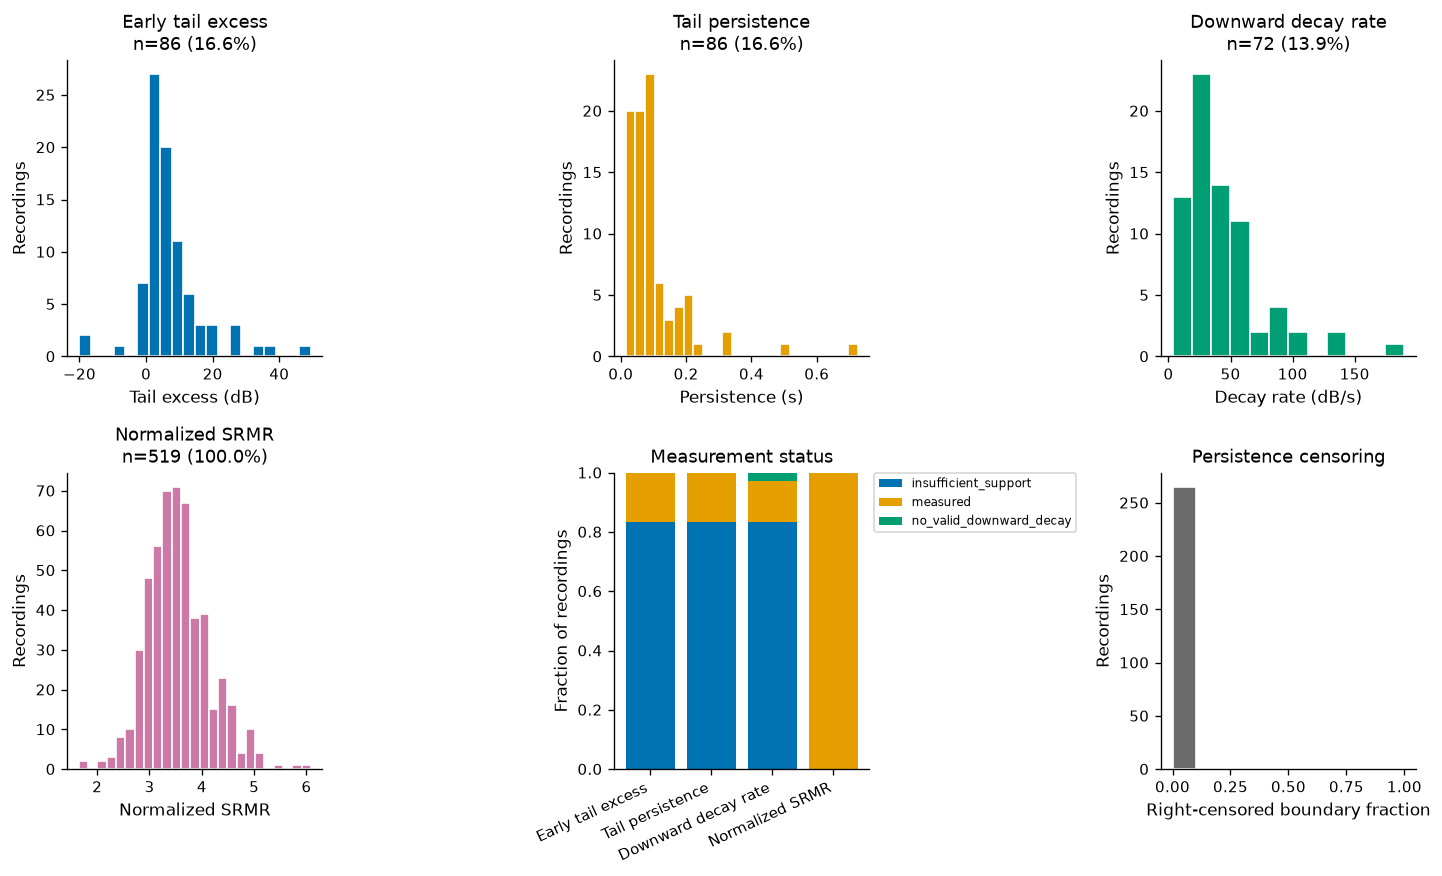

,feature,recordings,available_n,availability_fraction,availability_ci95_low,availability_ci95_high,median,q25,q75,minimum,maximum
0,qrev_tail_excess_100ms_db,519,86,0.165703,0.136194,0.200124,5.632035,2.161729,10.067196,-20.165303,49.473858
1,qrev_tail_persistence_median_sec,519,86,0.165703,0.136194,0.200124,0.075000,0.045000,0.112500,0.015000,0.725000
2,qrev_downward_decay_rate_db_per_sec,519,72,0.138728,0.111635,0.171130,34.092708,20.252478,54.972721,3.251983,190.021872
3,qrev_srmr_norm,519,519,1.000000,0.992653,1.000000,3.500913,3.146903,3.877454,1.651367,6.083459


,recordings,median_internal_boundaries,median_tail_valid_boundaries,median_persistence_valid_boundaries,median_decay_valid_boundaries,median_persistence_censored_fraction,median_srmr_memory_mb,maximum_srmr_memory_mb,resource_limited_srmr_n
0,519,11.0,1.0,1.0,0.0,0.0,22.67168,96.383972,0


,layer,check,passed,observed,required,action_if_failed,blocking
0,empirical,SRMR coverage is analysis-wide,True,"{'qrev_tail_excess_100ms_db': 0.166, 'qrev_tai...",SRMR availability >=0.95,inspect SRMR support or computation failures,True
1,empirical,conditional features are empirically character...,True,"{'qrev_tail_excess_100ms_db': 86, 'qrev_tail_p...",>=26 observations each,limit claims or reconsider support contract,True
2,empirical,availability/status summary complete,True,checked,all four features,repair status export,True
3,empirical,no SRMR memory crash or silent truncation,True,checked,no computation failure,inspect resource preflight/runtime,True
4,empirical,downstream availability analysis is prespecified,True,specified,label-blind here; phenotype association downst...,add analysis-stage missingness plan,True


In [10]:
empirical_summary = pd.DataFrame()
availability_summary = pd.DataFrame()
correlation_table = pd.DataFrame()
correlation_pairwise_n = pd.DataFrame()
support_summary = pd.DataFrame()
availability_by_support_tier = pd.DataFrame()
downstream_missingness_specification = pd.DataFrame([{
    "analysis_stage": "downstream clinical analysis; not feature extraction",
    "outcome": "feature availability (available versus unavailable)",
    "predictor": "prespecified ALS severity measure and cohort",
    "model": (
        "participant-clustered generalized linear model or "
        "mixed-effects logistic model, selected before outcome analysis"
    ),
    "purpose": (
        "test whether natural-boundary feature availability is "
        "associated with speech phenotype or cohort"
    ),
    "current_notebook_scope": (
        "label-blind measurement validation only; no clinical labels used"
    ),
}])


def wilson_interval(successes, total, z=1.959963984540054):
    if total <= 0:
        return np.nan, np.nan
    proportion = successes/total
    denominator = 1+(z**2)/total
    centre = (proportion+(z**2)/(2*total))/denominator
    half_width = (
        z*np.sqrt(
            proportion*(1-proportion)/total
            +(z**2)/(4*total**2)
        )/denominator
    )
    return centre-half_width, centre+half_width


if RUN_COHORT_EXTRACTION and len(recording_table):
    rows = []
    availability_rows = []
    for feature in ANALYSIS_FEATURES:
        values = pd.to_numeric(
            recording_table[feature], errors="coerce"
        )
        finite = values.loc[np.isfinite(values)]
        ci_low, ci_high = wilson_interval(
            len(finite), len(values)
        )
        rows.append({
            "feature": feature,
            "recordings": len(values),
            "available_n": len(finite),
            "availability_fraction": len(finite)/max(1, len(values)),
            "availability_ci95_low": ci_low,
            "availability_ci95_high": ci_high,
            "median": finite.median() if len(finite) else np.nan,
            "q25": finite.quantile(0.25) if len(finite) else np.nan,
            "q75": finite.quantile(0.75) if len(finite) else np.nan,
            "minimum": finite.min() if len(finite) else np.nan,
            "maximum": finite.max() if len(finite) else np.nan,
        })
        status_counts = recording_table[
            f"{feature}_status"
        ].astype(str).value_counts(dropna=False)
        for status, count in status_counts.items():
            availability_rows.append({
                "feature": feature,
                "status": status,
                "count": int(count),
                "fraction": count/max(1, len(recording_table)),
            })
    empirical_summary = pd.DataFrame(rows)
    availability_summary = pd.DataFrame(availability_rows)
    correlation_table = recording_table[
        list(ANALYSIS_FEATURES)
    ].corr(method="spearman", min_periods=20)
    correlation_pairwise_n = pd.DataFrame(
        index=ANALYSIS_FEATURES,
        columns=ANALYSIS_FEATURES,
        dtype=float,
    )
    for feature_a in ANALYSIS_FEATURES:
        for feature_b in ANALYSIS_FEATURES:
            correlation_pairwise_n.loc[
                feature_a, feature_b
            ] = int(
                recording_table[
                    [feature_a, feature_b]
                ].apply(
                    pd.to_numeric, errors="coerce"
                ).dropna().shape[0]
            )
    support_rows = []
    for feature in ANALYSIS_FEATURES:
        tier_column = f"{feature}_support_tier"
        for tier, local in recording_table.groupby(
            tier_column, dropna=False, sort=True
        ):
            available_n = int(
                pd.to_numeric(
                    local[feature], errors="coerce"
                ).notna().sum()
            )
            ci_low, ci_high = wilson_interval(
                available_n, len(local)
            )
            support_rows.append({
                "feature": feature,
                "support_tier": str(tier),
                "recordings": len(local),
                "available_n": available_n,
                "availability_fraction": (
                    available_n/max(1, len(local))
                ),
                "availability_ci95_low": ci_low,
                "availability_ci95_high": ci_high,
            })
    availability_by_support_tier = pd.DataFrame(support_rows)
    support_summary = pd.DataFrame([{
        "recordings": len(recording_table),
        "median_internal_boundaries": recording_table[
            "qrev_internal_boundary_count"
        ].median(),
        "median_tail_valid_boundaries": recording_table[
            "qrev_tail_valid_boundary_count"
        ].median(),
        "median_persistence_valid_boundaries": recording_table[
            "qrev_persistence_valid_boundary_count"
        ].median(),
        "median_decay_valid_boundaries": recording_table[
            "qrev_decay_valid_boundary_count"
        ].median(),
        "median_persistence_censored_fraction": recording_table[
            "qrev_persistence_right_censored_fraction"
        ].median(),
        "median_srmr_memory_mb": recording_table[
            "qrev_srmr_estimated_working_set_mb"
        ].median(),
        "maximum_srmr_memory_mb": recording_table[
            "qrev_srmr_estimated_working_set_mb"
        ].max(),
        "resource_limited_srmr_n": int(
            recording_table[
                "qrev_srmr_norm_status"
            ].eq("resource_limit").sum()
        ),
    }])
    minimum_empirical_n = max(
        20, math.ceil(0.05*len(recording_table))
    )
    empirical_checks = validation_frame([
        ValidationCheck(
            "empirical", "SRMR coverage is analysis-wide",
            float(
                empirical_summary.loc[
                    empirical_summary["feature"].eq(
                        "qrev_srmr_norm"
                    ),
                    "availability_fraction",
                ].iloc[0]
            ) >= 0.95,
            str(
                empirical_summary.set_index("feature")[
                    "availability_fraction"
                ].round(3).to_dict()
            ),
            "SRMR availability >=0.95",
            "inspect SRMR support or computation failures",
        ),
        ValidationCheck(
            "empirical",
            "conditional features are empirically characterizable",
            empirical_summary.loc[
                empirical_summary["feature"].isin(
                    CONDITIONAL_BOUNDARY_FEATURES
                ),
                "available_n",
            ].ge(minimum_empirical_n).all(),
            str(
                empirical_summary.set_index("feature")[
                    "available_n"
                ].to_dict()
            ),
            f">={minimum_empirical_n} observations each",
            "limit claims or reconsider support contract",
        ),
        ValidationCheck(
            "empirical", "availability/status summary complete",
            set(availability_summary["feature"])
            == set(ANALYSIS_FEATURES),
            "checked",
            "all four features",
            "repair status export",
        ),
        ValidationCheck(
            "empirical", "no SRMR memory crash or silent truncation",
            not recording_table[
                "qrev_srmr_norm_status"
            ].eq("computation_failed").any(),
            "checked",
            "no computation failure",
            "inspect resource preflight/runtime",
        ),
        ValidationCheck(
            "empirical",
            "downstream availability analysis is prespecified",
            len(downstream_missingness_specification) == 1
            and downstream_missingness_specification[
                "current_notebook_scope"
            ].str.contains("no clinical labels used").all(),
            "specified",
            "label-blind here; phenotype association downstream",
            "add analysis-stage missingness plan",
        ),
    ])
else:
    empirical_checks = validation_frame([
        ValidationCheck(
            "empirical", "cohort characterization completed",
            False, "NOT RUN", "completed",
            "enable cohort extraction",
        )
    ])

for frame, stem in [
    (empirical_summary, "qrev_v311_empirical_summary"),
    (availability_summary, "qrev_v311_availability_summary"),
    (
        correlation_table.reset_index().rename(
            columns={"index": "feature"}
        ),
        "qrev_v311_spearman_correlations",
    ),
    (
        correlation_pairwise_n.reset_index().rename(
            columns={"index": "feature"}
        ),
        "qrev_v311_spearman_pairwise_n",
    ),
    (support_summary, "qrev_v311_support_summary"),
    (
        availability_by_support_tier,
        "qrev_v311_availability_by_support_tier",
    ),
    (
        downstream_missingness_specification,
        "qrev_v311_downstream_missingness_specification",
    ),
    (empirical_checks, "qrev_v311_empirical_checks"),
]:
    save_table_bundle(frame, TABLES, stem)

if len(recording_table):
    fig, axes = plt.subplots(2, 3, figsize=(12.0, 7.4))
    feature_labels = {
        "qrev_tail_excess_100ms_db": (
            "Early tail excess", "Tail excess (dB)"
        ),
        "qrev_tail_persistence_median_sec": (
            "Tail persistence", "Persistence (s)"
        ),
        "qrev_downward_decay_rate_db_per_sec": (
            "Downward decay rate", "Decay rate (dB/s)"
        ),
        "qrev_srmr_norm": (
            "Normalized SRMR", "Normalized SRMR"
        ),
    }
    for ax, feature, color in zip(
        axes.flat[:4],
        ANALYSIS_FEATURES,
        [
            OKABE_ITO["blue"], OKABE_ITO["orange"],
            OKABE_ITO["green"], OKABE_ITO["purple"],
        ],
    ):
        values = pd.to_numeric(
            recording_table[feature], errors="coerce"
        ).dropna()
        ax.hist(
            values,
            bins="fd" if len(values) > 1 else 1,
            color=color,
            edgecolor="white",
        )
        ax.set(
            xlabel=feature_labels[feature][1],
            ylabel="Recordings",
            title=(
                f"{feature_labels[feature][0]}\n"
                f"n={len(values)} "
                f"({100*len(values)/len(recording_table):.1f}%)"
            ),
        )
    status_pivot = availability_summary.pivot(
        index="feature", columns="status", values="fraction"
    ).fillna(0)
    status_pivot = status_pivot.reindex(ANALYSIS_FEATURES)
    bottom = np.zeros(len(status_pivot))
    status_colors = [
        OKABE_ITO["blue"], OKABE_ITO["orange"],
        OKABE_ITO["green"], OKABE_ITO["purple"],
        OKABE_ITO["grey"], OKABE_ITO["vermillion"],
    ]
    for status_index, status in enumerate(status_pivot.columns):
        color = status_colors[
            status_index % len(status_colors)
        ]
        axes[1, 1].bar(
            np.arange(len(status_pivot)),
            status_pivot[status],
            bottom=bottom,
            label=status,
            color=color,
        )
        bottom += status_pivot[status].to_numpy()
    axes[1, 1].set_xticks(
        np.arange(len(status_pivot)),
        [
            feature_labels[name][0]
            for name in status_pivot.index
        ],
        rotation=25,
        ha="right",
    )
    axes[1, 1].set(
        ylabel="Fraction of recordings",
        ylim=(0, 1),
        title="Measurement status",
    )
    axes[1, 1].legend(
        fontsize=7,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
    )
    axes[1, 2].hist(
        recording_table[
            "qrev_persistence_right_censored_fraction"
        ].dropna(),
        bins=np.linspace(0, 1, 11),
        color=OKABE_ITO["grey"],
        edgecolor="white",
    )
    axes[1, 2].set(
        xlabel="Right-censored boundary fraction",
        ylabel="Recordings",
        title="Persistence censoring",
    )
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qrev_empirical_distributions",
        caption=(
            "QREV v3.1 empirical feature distributions, availability "
            "states, and persistence censoring in the frozen cohort."
        ),
        alt_text=(
            "Four feature histograms, a stacked availability chart, "
            "and a histogram of persistence censoring fractions."
        ),
    )
    plt.show()
display(empirical_summary)
display(support_summary)
display(empirical_checks)


## 10. Negative-result and analysis-boundary audit


In [11]:
excluded_outputs = pd.DataFrame([
    {
        "candidate": "qrev_tail_excess_200ms_db",
        "disposition": "sensitivity_only",
        "reason": (
            "Correlated alternate window; not independent evidence."
        ),
    },
    {
        "candidate": "qrev_tail_energy_ratio_100ms",
        "disposition": "excluded_redundant_transform",
        "reason": (
            "Exact monotonic transform of the dB tail contrast."
        ),
    },
    {
        "candidate": "qrev_nondecreasing_boundary_fraction",
        "disposition": "diagnostic_only",
        "reason": (
            "May reflect echo, breath, noise change, or offset error."
        ),
    },
    {
        "candidate": "qrev_floor_dbfs_and_iqr",
        "disposition": "diagnostic_only",
        "reason": (
            "Local-floor context and reliability, not reverberation severity."
        ),
    },
    {
        "candidate": "QREV_v2.2_validation_exceptions",
        "disposition": "prohibited",
        "reason": (
            "A failed blocking scientific gate cannot be reclassified "
            "as an exception to create a freeze."
        ),
    },
])
analysis_columns_lower = {
    column.lower() for column in analysis_feature_table.columns
} if len(analysis_feature_table) else set()
negative_checks = validation_frame([
    ValidationCheck(
        "negative_result",
        "analysis table contains only prespecified features",
        all(feature in analysis_columns_lower for feature in ANALYSIS_FEATURES)
        and not any(
            candidate in analysis_columns_lower
            for candidate in [
                "qrev_tail_excess_200ms_db",
                "qrev_tail_energy_ratio_100ms",
            ]
        ),
        "checked",
        "exact analysis set",
        "repair export schema",
    ),
    ValidationCheck(
        "negative_result",
        "no failed-gate exception mechanism exists",
        "exception" not in " ".join(
            analysis_feature_table.columns
        ).lower(),
        "absent",
        "absent",
        "remove exception pathway",
    ),
])
save_table_bundle(
    excluded_outputs, TABLES, "qrev_v311_excluded_outputs"
)
save_table_bundle(
    negative_checks, TABLES, "qrev_v311_negative_result_checks"
)
display(excluded_outputs)
display(negative_checks)


,candidate,disposition,reason
0,qrev_tail_excess_200ms_db,sensitivity_only,Correlated alternate window; not independent e...
1,qrev_tail_energy_ratio_100ms,excluded_redundant_transform,Exact monotonic transform of the dB tail contr...
2,qrev_nondecreasing_boundary_fraction,diagnostic_only,"May reflect echo, breath, noise change, or off..."
3,qrev_floor_dbfs_and_iqr,diagnostic_only,"Local-floor context and reliability, not rever..."
4,QREV_v2.2_validation_exceptions,prohibited,A failed blocking scientific gate cannot be re...


,layer,check,passed,observed,required,action_if_failed,blocking
0,negative_result,analysis table contains only prespecified feat...,True,checked,exact analysis set,repair export schema,True
1,negative_result,no failed-gate exception mechanism exists,True,absent,absent,remove exception pathway,True


## 11. Label-blind reviewer gallery

Selection uses only QREV feature quantiles and measurement-support
diagnostics. It includes three empirical quantiles for each feature, two
unavailable cases with relatively high boundary opportunity, and two
minimum-support cases. High-censoring examples are added only when censoring
actually occurs. This avoids presenting ordinary zero-censoring recordings as
special cases and guarantees that availability is visually audited.

The gallery is not used to tune thresholds. Each audio file is decoded,
plotted, and released before the next file. These visualizations assess
residual behavior; they do not identify a discrete echo delay or prove a
room-acoustic mechanism.


In [12]:
gallery_index = pd.DataFrame()


def choose_gallery(table):
    candidates = []
    for feature in ANALYSIS_FEATURES:
        local = table.loc[
            pd.to_numeric(
                table[feature], errors="coerce"
            ).notna()
        ]
        for quantile in [0.05, 0.50, 0.95]:
            if not len(local):
                continue
            target = local[feature].quantile(quantile)
            index = (local[feature]-target).abs().idxmin()
            candidates.append((
                str(local.loc[index, "logical_recording_id"]),
                f"{feature}_q{int(100*quantile):02d}",
            ))
    censoring = pd.to_numeric(
        table["qrev_persistence_right_censored_fraction"],
        errors="coerce",
    )
    if censoring.fillna(0).gt(0).any():
        diagnostic = table.loc[censoring.gt(0)].sort_values(
            "qrev_persistence_right_censored_fraction",
            ascending=False,
        ).head(2)
        for recording_id in diagnostic["logical_recording_id"]:
            candidates.append((
                str(recording_id), "high_persistence_censoring"
            ))
    unavailable = table.loc[
        table[
            "qrev_tail_excess_100ms_db_status"
        ].ne("measured")
    ].sort_values(
        "qrev_internal_boundary_count", ascending=False
    ).head(2)
    for recording_id in unavailable["logical_recording_id"]:
        candidates.append((
            str(recording_id), "availability_audit"
        ))
    minimum_support = table.loc[
        table[
            "qrev_tail_excess_100ms_db_support_tier"
        ].eq("minimum")
    ].sort_values(
        "qrev_tail_valid_boundary_count"
    ).head(2)
    for recording_id in minimum_support["logical_recording_id"]:
        candidates.append((
            str(recording_id), "minimum_support_audit"
        ))
    frame = pd.DataFrame(
        candidates,
        columns=["logical_recording_id", "selection_reason"],
    )
    if not len(frame):
        return frame
    return (
        frame.groupby(
            "logical_recording_id", as_index=False, sort=False
        )[
            "selection_reason"
        ]
        .agg(";".join)
        .head(18)
    )


def plot_gallery_recording(recording_id, reason):
    row = frozen["recordings"].set_index(
        "logical_recording_id"
    ).loc[str(recording_id)]
    views = decode_audio_views(
        media_path_for(row),
        ffmpeg=shutil.which("ffmpeg"),
        ffprobe=shutil.which("ffprobe"),
        analysis_rate=FS,
    )
    intervals = intervals_for(recording_id)
    extraction = extract_qrev(
        views.analysis_16k,
        FS,
        strict_speech=intervals,
        logical_recording_id=recording_id,
        compute_srmr=True,
    )
    ledger = extraction.boundary_ledger
    selected = (
        ledger.loc[ledger["tail_eligible"].astype(bool)].head(1)
        if len(ledger) else pd.DataFrame()
    )
    time = np.arange(len(views.analysis_16k))/FS
    stride = max(1, len(time)//12000)
    fig, axes = plt.subplots(3, 1, figsize=(10.2, 7.0))
    axes[0].plot(
        time[::stride],
        views.analysis_16k[::stride],
        color=OKABE_ITO["grey"],
        linewidth=0.5,
    )
    for interval in intervals:
        axes[0].axvspan(
            interval.start_sec,
            interval.end_sec,
            color=OKABE_ITO["sky"],
            alpha=0.16,
        )
    axes[0].set(
        xlabel="Original recording time (s)",
        ylabel="Amplitude",
        title=f"{recording_id} - {reason}",
    )
    axes[0].set_title(
        f"{recording_id} — "
        f"{reason.replace('_', ' ').replace(';', '; ')}"
    )
    if len(selected):
        boundary = selected.iloc[0]
        trace = boundary_envelope_trace(
            views.analysis_16k,
            FS,
            boundary["speech_offset_sec"],
            boundary["pause_end_sec"],
        )
        axes[1].plot(
            trace["relative_mid_sec"],
            trace["ac_rms_dbfs"],
            "o-", markersize=3,
            color=OKABE_ITO["blue"],
        )
        axes[1].axvspan(
            0, PARAMETERS.early_tail_end_ms/1000,
            color=OKABE_ITO["orange"], alpha=0.18,
            label="early tail",
        )
        axes[1].axvspan(
            PARAMETERS.floor_start_ms/1000,
            PARAMETERS.floor_end_ms/1000,
            color=OKABE_ITO["green"], alpha=0.18,
            label="late floor",
        )
        axes[1].axhline(
            boundary["floor_dbfs"],
            color=OKABE_ITO["green"],
            linestyle="--",
        )
        axes[1].set(
            xlabel="Time after speech offset (s)",
            ylabel="30-ms AC-RMS (dBFS)",
            title=boundary["boundary_id"],
        )
        axes[1].legend(fontsize=8)
    else:
        axes[1].text(
            0.5, 0.5, "No eligible natural boundary",
            transform=axes[1].transAxes,
            ha="center", va="center",
        )
        axes[1].set_axis_off()
    if len(ledger):
        axes[2].scatter(
            ledger["pause_duration_sec"],
            ledger["tail_excess_100ms_db"],
            c=ledger["tail_eligible"].astype(int),
            cmap="viridis",
            s=24,
        )
    axes[2].set(
        xlabel="Pause duration (s)",
        ylabel="Boundary tail excess (dB)",
        title=(
            "Boundary support (residual descriptor; not echo identity)"
        ),
    )
    fig.tight_layout()
    save_publication_figure(
        fig,
        GALLERY,
        f"qrev_gallery_{recording_id}",
        caption=(
            f"Label-blind QREV audit gallery: {recording_id}; "
            f"selection={reason}."
        ),
        alt_text=(
            "Waveform and frozen speech intervals, an on-demand "
            "post-offset envelope with early and floor windows, and "
            "boundary tail excess against pause duration."
        ),
        dpi=300,
    )
    plt.close(fig)
    del views, extraction
    gc.collect()


if BUILD_GALLERY and RUN_COHORT_EXTRACTION and len(recording_table):
    gallery_index = choose_gallery(recording_table)
    for row in gallery_index.itertuples(index=False):
        try:
            plot_gallery_recording(
                str(row.logical_recording_id),
                str(row.selection_reason),
            )
        except Exception as exc:
            gallery_index.loc[
                gallery_index["logical_recording_id"].eq(
                    row.logical_recording_id
                ),
                "gallery_error",
            ] = str(exc)
    save_table_bundle(
        gallery_index, GALLERY, "qrev_gallery_index"
    )
else:
    gallery_index = pd.DataFrame([{
        "logical_recording_id": pd.NA,
        "selection_reason": "NOT RUN",
    }])

gallery_reason = gallery_index.get(
    "selection_reason", pd.Series(dtype=str)
).fillna("").astype(str)
unavailable_exist = bool(
    len(recording_table)
    and recording_table[
        "qrev_tail_excess_100ms_db_status"
    ].ne("measured").any()
)
minimum_support_exist = bool(
    len(recording_table)
    and recording_table[
        "qrev_tail_excess_100ms_db_support_tier"
    ].eq("minimum").any()
)
positive_censoring_exists = bool(
    len(recording_table)
    and pd.to_numeric(
        recording_table[
            "qrev_persistence_right_censored_fraction"
        ],
        errors="coerce",
    ).fillna(0).gt(0).any()
)
gallery_checks = validation_frame([
    ValidationCheck(
        "gallery",
        "all four features represented by quantile examples",
        all(
            gallery_reason.str.contains(
                feature, regex=False
            ).any()
            for feature in ANALYSIS_FEATURES
        ),
        str(len(gallery_index)),
        "q05/q50/q95 candidates for every feature",
        "repair quantile selection",
    ),
    ValidationCheck(
        "gallery",
        "unavailable cases represented when present",
        (
            not unavailable_exist
            or gallery_reason.str.contains(
                "availability_audit", regex=False
            ).any()
        ),
        str(unavailable_exist),
        "at least one availability audit case",
        "repair gallery capacity or selection order",
    ),
    ValidationCheck(
        "gallery",
        "minimum-support cases represented when present",
        (
            not minimum_support_exist
            or gallery_reason.str.contains(
                "minimum_support_audit", regex=False
            ).any()
        ),
        str(minimum_support_exist),
        "at least one minimum-support audit case",
        "repair gallery capacity or selection order",
    ),
    ValidationCheck(
        "gallery",
        "positive-censoring cases represented when present",
        (
            not positive_censoring_exists
            or gallery_reason.str.contains(
                "high_persistence_censoring", regex=False
            ).any()
        ),
        str(positive_censoring_exists),
        "at least one positive-censoring case, if any exist",
        "repair censoring selection",
    ),
    ValidationCheck(
        "gallery",
        "gallery rendered without errors",
        bool(
            len(gallery_index)
            and not gallery_index.get(
                "gallery_error", pd.Series(dtype=object)
            ).notna().any()
        ),
        str(len(gallery_index)),
        "nonempty gallery and zero rendering errors",
        "repair failed gallery rendering",
    ),
])
save_table_bundle(
    gallery_checks, GALLERY, "qrev_gallery_checks"
)
display(gallery_index)
display(gallery_checks)


,logical_recording_id,selection_reason
0,TIBD01_270_1_20211201_240_PSG_BAMBOO,qrev_tail_excess_100ms_db_q05
1,TIBD113_1003_1_20241107_240_PSG_BAMBOO,qrev_tail_excess_100ms_db_q50
2,TIBD66_270_2_20231010_240_PSG_BAMBOO,qrev_tail_excess_100ms_db_q95
3,C05-1_1075_1_20260420_240_PSG_BAMBOO,qrev_tail_persistence_median_sec_q05
4,CAPT0000030_272_2_20230711_240_PSG_BAMBOO,qrev_tail_persistence_median_sec_q50
5,CAPT0000020_272_1_20230803_240_PSG_BAMBOO,qrev_tail_persistence_median_sec_q95
6,TIBD31_1003_1_20220511_240_PSG_BAMBOO,qrev_downward_decay_rate_db_per_sec_q05
7,TIBD84_1003_1_20231013_240_PSG_BAMBOO,qrev_downward_decay_rate_db_per_sec_q50
8,TIBD107_270_2_20250407_240_PSG_BAMBOO,qrev_downward_decay_rate_db_per_sec_q95
9,TIBD48_270_2_20230612_240_PSG_BAMBOO,qrev_srmr_norm_q05


,layer,check,passed,observed,required,action_if_failed,blocking
0,gallery,all four features represented by quantile exam...,True,16,q05/q50/q95 candidates for every feature,repair quantile selection,True
1,gallery,unavailable cases represented when present,True,True,at least one availability audit case,repair gallery capacity or selection order,True
2,gallery,minimum-support cases represented when present,True,True,at least one minimum-support audit case,repair gallery capacity or selection order,True
3,gallery,positive-censoring cases represented when present,True,False,"at least one positive-censoring case, if any e...",repair censoring selection,True
4,gallery,gallery rendered without errors,True,16,nonempty gallery and zero rendering errors,repair failed gallery rendering,True


In [13]:
gallery_index = pd.read_csv(
    GALLERY / "qrev_gallery_index.csv"
)
gallery_checks = pd.read_csv(
    GALLERY / "qrev_gallery_checks.csv"
)

if len(gallery_index) != 16:
    raise RuntimeError(
        f"Expected 16 completed gallery cases; found {len(gallery_index)}."
    )

if not gate_passed(gallery_checks):
    display(gallery_checks)
    raise RuntimeError("Saved gallery checks do not all pass.")

reasons = gallery_index["selection_reason"].fillna("").astype(str)

if not reasons.str.contains(
    "availability_audit", regex=False
).any():
    raise RuntimeError("Saved gallery lacks availability-audit cases.")

if not reasons.str.contains(
    "minimum_support_audit", regex=False
).any():
    raise RuntimeError("Saved gallery lacks minimum-support cases.")

display(gallery_index)
display(gallery_checks)
print("Existing completed gallery loaded successfully.")

,logical_recording_id,selection_reason
0,TIBD01_270_1_20211201_240_PSG_BAMBOO,qrev_tail_excess_100ms_db_q05
1,TIBD113_1003_1_20241107_240_PSG_BAMBOO,qrev_tail_excess_100ms_db_q50
2,TIBD66_270_2_20231010_240_PSG_BAMBOO,qrev_tail_excess_100ms_db_q95
3,C05-1_1075_1_20260420_240_PSG_BAMBOO,qrev_tail_persistence_median_sec_q05
4,CAPT0000030_272_2_20230711_240_PSG_BAMBOO,qrev_tail_persistence_median_sec_q50
5,CAPT0000020_272_1_20230803_240_PSG_BAMBOO,qrev_tail_persistence_median_sec_q95
6,TIBD31_1003_1_20220511_240_PSG_BAMBOO,qrev_downward_decay_rate_db_per_sec_q05
7,TIBD84_1003_1_20231013_240_PSG_BAMBOO,qrev_downward_decay_rate_db_per_sec_q50
8,TIBD107_270_2_20250407_240_PSG_BAMBOO,qrev_downward_decay_rate_db_per_sec_q95
9,TIBD48_270_2_20230612_240_PSG_BAMBOO,qrev_srmr_norm_q05


,layer,check,passed,observed,required,action_if_failed,blocking
0,gallery,all four features represented by quantile exam...,True,16,q05/q50/q95 candidates for every feature,repair quantile selection,True
1,gallery,unavailable cases represented when present,True,True,at least one availability audit case,repair gallery capacity or selection order,True
2,gallery,minimum-support cases represented when present,True,True,at least one minimum-support audit case,repair gallery capacity or selection order,True
3,gallery,positive-censoring cases represented when present,True,False,"at least one positive-censoring case, if any e...",repair censoring selection,True
4,gallery,gallery rendered without errors,True,16,nonempty gallery and zero rendering errors,repair failed gallery rendering,True


Existing completed gallery loaded successfully.


## 12. Scientific gates, immutable freeze, and central-table export


In [14]:
if RUN_PACKAGE_TESTS:
    completed = subprocess.run(
        [
            sys.executable, "-m", "pytest",
            "tests/test_qrev_v31.py",
            "tests/test_qrev_notebook_v311.py",
            "-q",
        ],
        cwd=ROOT,
        capture_output=True,
        text=True,
    )
    package_test_passed = completed.returncode == 0
    package_test_observed = (
        completed.stdout + "\n" + completed.stderr
    ).strip()[-1600:]
else:
    package_test_passed = bool(PACKAGE_TESTS_CONFIRMED)
    package_test_observed = (
        "confirmed externally"
        if PACKAGE_TESTS_CONFIRMED else "NOT RUN"
    )

review_passed = bool(
    QREV_REVIEW_DECISION == "ACCEPT_QREV_V311"
    and QREV_REVIEWER.strip()
    and QREV_REVIEW_RATIONALE.strip()
    and len(gallery_index)
    and not gallery_index.get(
        "gallery_error", pd.Series(dtype=object)
    ).notna().any()
)
layer_summary = validation_frame([
    ValidationCheck(
        "technical", "package tests",
        package_test_passed,
        package_test_observed,
        "all pass",
        "repair package/tests",
    ),
    ValidationCheck(
        "technical", "registry contract",
        gate_passed(registry_checks),
        f"{int(registry_checks['passed'].sum())}/{len(registry_checks)}",
        "all pass",
        "repair registry",
    ),
    ValidationCheck(
        "technical", "formula, determinism, and SRMR reference",
        gate_passed(formula_checks),
        f"{int(formula_checks['passed'].sum())}/{len(formula_checks)}",
        "all pass",
        "restore estimator/runtime",
    ),
    ValidationCheck(
        "scientific", "factorial RIR and discriminant controls",
        gate_passed(construct_checks),
        f"{int(construct_checks['passed'].sum())}/{len(construct_checks)}",
        "all pass",
        "revise estimator or claim",
    ),
    ValidationCheck(
        "scientific", "floor and censoring calibration",
        gate_passed(floor_checks),
        f"{int(floor_checks['passed'].sum())}/{len(floor_checks)}",
        "all pass",
        "repair censoring policy",
    ),
    ValidationCheck(
        "input", "frozen input contract",
        gate_passed(input_checks),
        f"{int(input_checks['passed'].sum())}/{len(input_checks)}",
        "all pass",
        "repair frozen inputs",
    ),
    ValidationCheck(
        "extraction", "cohort extraction and reconstruction",
        gate_passed(extraction_checks),
        f"{int(extraction_checks['passed'].sum())}/{len(extraction_checks)}",
        "all pass",
        "resolve extraction",
    ),
    ValidationCheck(
        "scientific", "codec/resampling stability",
        gate_passed(codec_checks),
        f"{int(codec_checks['passed'].sum())}/{len(codec_checks)}",
        "all pass",
        "qualify codec dependence",
    ),
    ValidationCheck(
        "scientific", "boundary/window/support robustness",
        gate_passed(robustness_checks),
        f"{int(robustness_checks['passed'].sum())}/{len(robustness_checks)}",
        "all pass",
        "revise estimator/support",
    ),
    ValidationCheck(
        "empirical", "cohort distributions and availability",
        gate_passed(empirical_checks),
        f"{int(empirical_checks['passed'].sum())}/{len(empirical_checks)}",
        "all pass",
        "reconsider feature feasibility",
    ),
    ValidationCheck(
        "scientific", "negative-result separation",
        gate_passed(negative_checks),
        f"{int(negative_checks['passed'].sum())}/{len(negative_checks)}",
        "all pass",
        "repair analysis/audit separation",
    ),
    ValidationCheck(
        "technical", "gallery construction contract",
        gate_passed(gallery_checks),
        f"{int(gallery_checks['passed'].sum())}/{len(gallery_checks)}",
        "all pass",
        "repair gallery construction",
    ),
    ValidationCheck(
        "review", "gallery reviewed and accepted",
        review_passed,
        QREV_REVIEW_DECISION,
        "ACCEPT_QREV_V311 with reviewer/rationale",
        "complete scientific review",
    ),
    ValidationCheck(
        "integration", "central registry/CLI approved",
        PACKAGE_INTEGRATION_APPROVED,
        str(PACKAGE_INTEGRATION_APPROVED),
        "True after family freeze",
        "integrate downstream",
        blocking=False,
    ),
])
save_table_bundle(
    layer_summary, TABLES, "qrev_v311_gate_summary"
)
display(layer_summary)

all_blocking_layers_pass = gate_passed(layer_summary)
freeze_requested_safely = bool(
    PUBLISH_AND_FREEZE_QREV_V311
    and all_blocking_layers_pass
)
manifest = {
    "measurement_version": VALIDATION_RELEASE,
    "estimator_implementation_version": (
        ESTIMATOR_IMPLEMENTATION_VERSION
    ),
    "release_scope": (
        "validation-policy and gallery correction; feature "
        "algorithms unchanged"
    ),
    "candidate_only": not freeze_requested_safely,
    "all_blocking_layers_pass": all_blocking_layers_pass,
    "publish_and_freeze_requested": PUBLISH_AND_FREEZE_QREV_V311,
    "analysis_features": list(ANALYSIS_FEATURES),
    "primary_features": list(PRIMARY_FEATURES),
    "conditional_boundary_features": list(
        CONDITIONAL_BOUNDARY_FEATURES
    ),
    "broadly_available_comparator_features": list(
        BROADLY_AVAILABLE_COMPARATOR_FEATURES
    ),
    "parameters": PARAMETERS.to_dict(),
    "implementation_sha256": sha256_file(
        ROOT / "src/paper1_qc/qrev.py"
    ),
    "vendored_srmrpy_sha256": sha256_file(
        ROOT / "src/paper1_qc/_vendor/srmrpy/srmr.py"
    ),
    "srmr": {
        "variant": SRMR_VARIANT,
        "upstream_commit": SRMR_UPSTREAM_COMMIT,
        "gammatone_version": SRMR_GAMMATONE_VERSION,
        "pinned_regression_value": SRMR_PINNED_REGRESSION_VALUE,
        "historical_fixture_discrepancy_table": (
            "tables/qrev_v311_srmr_reference_audit.csv"
        ),
    },
    "gate_table_sha256": sha256_file(
        TABLES / "qrev_v311_gate_summary.csv"
    ),
    "claim_boundary": {
        "allowed": [
            "observable post-speech residual magnitude",
            "bounded post-speech persistence",
            "conditional downward residual decay",
            "normalized no-reference SRMR comparator",
            "behavior compatible with reverberation or echo",
        ],
        "forbidden": [
            "RT60", "EDT", "C50", "C80", "D50",
            "DRR", "STI", "room impulse response",
            "discrete-delay echo detector",
            "echo identity",
        ],
    },
    "availability_analysis": {
        "feature_extraction_scope": (
            "label-blind availability and support reporting"
        ),
        "downstream_specification_table": (
            "tables/"
            "qrev_v311_downstream_missingness_specification.csv"
        ),
        "interpretation": (
            "natural-boundary availability may be related to "
            "speech phenotype or cohort and is not missing at random "
            "by assumption"
        ),
    },
    "failed_gate_exception_policy": "PROHIBITED",
    "scientific_review": {
        "decision": QREV_REVIEW_DECISION,
        "reviewer": QREV_REVIEWER,
        "rationale": QREV_REVIEW_RATIONALE,
    },
}
if PUBLISH_AND_FREEZE_QREV_V311 and not all_blocking_layers_pass:
    failed = layer_summary.loc[
        layer_summary["blocking"].astype(bool)
        & ~layer_summary["passed"].astype(bool),
        ["layer", "check", "observed", "action_if_failed"],
    ]
    display(failed)
    raise RuntimeError(
        "QREV freeze requested, but blocking layers failed. "
        "Failed gates cannot be waived or reclassified."
    )

frozen_root = (
    MAIN_OUTPUTS / "02_FEATURE_FREEZE" / "reverberation"
    / VALIDATION_RELEASE
)
notebook_source = (
    ROOT / "notebooks" / "02_feature_extraction"
    / "02c_reverberation_QREV_v3_1_1.ipynb"
)
if freeze_requested_safely:
    manifest["stage_file_sha256"] = {
        str(path.relative_to(STAGE)): sha256_file(path)
        for path in sorted(STAGE.rglob("*"))
        if path.is_file()
        and path.name not in {
            "qrev_v311_candidate_manifest.json",
            "qrev_v311_frozen_manifest.json",
        }
    }
    write_json(
        manifest, AUDIT / "qrev_v311_frozen_manifest.json"
    )
    temporary_frozen_root = frozen_root.with_name(
        f".{frozen_root.name}.copying"
    )
    if frozen_root.exists() or temporary_frozen_root.exists():
        raise FileExistsError(
            "Refusing to overwrite an existing immutable QREV "
            f"freeze: {frozen_root}"
        )
    frozen_root.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(STAGE, temporary_frozen_root)
    notebook_directory = temporary_frozen_root / "notebook"
    notebook_directory.mkdir(parents=True, exist_ok=True)
    if not notebook_source.exists():
        raise FileNotFoundError(
            f"Save the notebook before freezing: {notebook_source}"
        )
    shutil.copy2(
        notebook_source,
        notebook_directory
        / "02c_reverberation_QREV_v3_1_1_FROZEN.ipynb",
    )
    checksum_rows = [
        {
            "relative_path": str(
                path.relative_to(temporary_frozen_root)
            ).replace("\\", "/"),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in sorted(temporary_frozen_root.rglob("*"))
        if path.is_file()
        and path.name != "FREEZE_SHA256SUMS.csv"
    ]
    pd.DataFrame(checksum_rows).to_csv(
        temporary_frozen_root / "FREEZE_SHA256SUMS.csv",
        index=False,
    )
    temporary_frozen_root.replace(frozen_root)
    display(Markdown(
        "## FROZEN - QREV v3.1 passed every blocking layer\n\n"
        f"Immutable snapshot: `{frozen_root}`"
    ))
else:
    write_json(
        manifest, AUDIT / "qrev_v311_candidate_manifest.json"
    )
    display(Markdown(
        "## CANDIDATE ONLY\n\n"
        "This is the required first-run status. Review every gate, "
        "table, figure, and gallery before requesting a freeze."
    ))


,layer,check,passed,observed,required,action_if_failed,blocking
0,technical,package tests,True,[32m.[0m[32m.[0m[32m.[0m[32m.[0m[32m....,all pass,repair package/tests,True
1,technical,registry contract,True,5/5,all pass,repair registry,True
2,technical,"formula, determinism, and SRMR reference",True,4/4,all pass,restore estimator/runtime,True
3,scientific,factorial RIR and discriminant controls,True,10/10,all pass,revise estimator or claim,True
4,scientific,floor and censoring calibration,True,2/2,all pass,repair censoring policy,True
5,input,frozen input contract,True,3/3,all pass,repair frozen inputs,True
6,extraction,cohort extraction and reconstruction,True,6/6,all pass,resolve extraction,True
7,scientific,codec/resampling stability,True,3/3,all pass,qualify codec dependence,True
8,scientific,boundary/window/support robustness,True,10/10,all pass,revise estimator/support,True
9,empirical,cohort distributions and availability,True,5/5,all pass,reconsider feature feasibility,True


## FROZEN - QREV v3.1 passed every blocking layer

Immutable snapshot: `C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FREEZE\reverberation\qrev-v3.1.1`

In [15]:
# Export only an immutable frozen table. Candidate runs skip cleanly.
CENTRAL_FEATURE_TABLES = MAIN_OUTPUTS / "02_FEATURE_TABLES"
FROZEN_MANIFEST = (
    frozen_root / "audit" / "qrev_v311_frozen_manifest.json"
)
SOURCE_TABLES = frozen_root / "tables"
SOURCE_FILES = [
    SOURCE_TABLES / "qrev_v311_analysis_features.csv",
    SOURCE_TABLES / "qrev_v311_analysis_features.parquet",
]


def export_frozen_qrev_table():
    if any(not path.exists() for path in SOURCE_FILES):
        raise FileNotFoundError(
            "Frozen QREV recording-table bundle is incomplete."
        )
    frozen_csv = pd.read_csv(SOURCE_FILES[0])
    missing = [
        column
        for column in ["logical_recording_id", *ANALYSIS_FEATURES]
        if column not in frozen_csv
    ]
    if missing:
        raise ValueError(
            f"Frozen table lacks required columns: {missing}"
        )
    if frozen_csv[
        "logical_recording_id"
    ].astype(str).duplicated().any():
        raise ValueError(
            "Frozen QREV table contains duplicate recording IDs."
        )
    CENTRAL_FEATURE_TABLES.mkdir(parents=True, exist_ok=True)
    rows = []
    for source_path in SOURCE_FILES:
        destination = CENTRAL_FEATURE_TABLES / source_path.name
        source_hash = sha256_file(source_path)
        if destination.exists():
            if sha256_file(destination) != source_hash:
                raise FileExistsError(
                    "Refusing to overwrite different central "
                    f"table: {destination}"
                )
            action = "already present and identical"
        else:
            shutil.copy2(source_path, destination)
            if sha256_file(destination) != source_hash:
                raise RuntimeError(
                    f"Hash verification failed: {destination}"
                )
            action = "copied and hash-verified"
        rows.append({
            "file": destination.name,
            "action": action,
            "rows": len(frozen_csv),
            "columns": len(frozen_csv.columns),
            "sha256": source_hash,
        })
    return pd.DataFrame(rows)


if FROZEN_MANIFEST.exists():
    display(export_frozen_qrev_table())
else:
    display(Markdown(
        "### Central export skipped\n\n"
        "No unfrozen QREV table was copied into "
        "`MAIN outputs/02_FEATURE_TABLES`."
    ))


,file,action,rows,columns,sha256
0,qrev_v311_analysis_features.csv,copied and hash-verified,519,34,b97e7d60702592aa69ede1c59e699d91bc150ed2cdb145...
1,qrev_v311_analysis_features.parquet,copied and hash-verified,519,34,9dc9c6463ae9cd1e95e042061367e61812dd84916febd6...
